# Cross-Institutional Generalization in Polyp Segmentation
### MixStyle • Fourier Amplitude Mixing • Focal Tversky Loss with ResUNet++

**Authors**: Mostafina Monir Mrimmoyee, Noshin Nawar, Umme Hunny Khan  
**Lab**: Pattern Recognition Lab, Islamic University of Technology  
**Date**: July 2026

**Goal**: Improve cross-institutional robustness of colonoscopy polyp segmentation through systematic ablation.

**Training Domains**: Kvasir-SEG + CVC-ClinicDB  
**OOD Test Domains**: CVC-ColonDB + ETIS-Larib  

**No target-domain images are used during training.**

## 1. Setup & Configuration

- Select GPU (P100 / T4 recommended)
- Add the following datasets from Kaggle:
  - `kvasir-seg` (or `simula-kvasir-seg`)
  - `cvcclinicdb`
  - `cvc-colondb`
  - `etis-laribpolypdb`
- Or use a combined dataset if available.

In [1]:
# ============================================================
# FIXED INSTALLATION CELL (Run this first)
# ============================================================

!pip install -q --upgrade pip
!pip install -q segmentation-models-pytorch
!pip install -q albumentations
!pip install -q opencv-python-headless

# Optional: for CRF (can be skipped if you want to avoid the error)
# !pip install -q git+https://github.com/lucasb-eyer/pydensecrf.git

print("Installation completed successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 6.5 MB/s eta 0:00:0000:0100:01
Installation completed successfully!


In [2]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.auto import tqdm
import cv2
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
print("All libraries imported successfully!")

Using device: cuda
All libraries imported successfully!


In [70]:
# ============================================================
# EXPERIMENT CONTROL CENTER
# Change only this number and re-run from here
# ============================================================
EXPERIMENT_ID = 5         # 0 → 5

EXPERIMENT_CONFIG = {
    0: {"name": "Baseline_UNet_BCE_Dice",          "backbone": "unet",      "loss": "bce_dice", "mixstyle": False, "fourier": False, "crf": False, "tta": False},
    1: {"name": "ResUNet++_BCE_Dice",              "backbone": "resunetpp", "loss": "bce_dice", "mixstyle": False, "fourier": False, "crf": False, "tta": False},
    2: {"name": "ResUNet++_BCE_Dice_MixStyle",     "backbone": "resunetpp", "loss": "bce_dice", "mixstyle": True,  "fourier": False, "crf": False, "tta": False},
    3: {"name": "ResUNet++_FocalTversky",          "backbone": "resunetpp", "loss": "focal_tversky", "mixstyle": False, "fourier": False, "crf": False, "tta": False},
    4: {"name": "ResUNet++_FocalTversky_MixStyle_Fourier", "backbone": "resunetpp", "loss": "focal_tversky", "mixstyle": True, "fourier": True, "crf": False, "tta": False},
    5: {"name": "Best_Model_CRF_TTA",              "backbone": "resunetpp", "loss": "focal_tversky", "mixstyle": True,  "fourier": True,  "crf": True,  "tta": True},
}

cfg = EXPERIMENT_CONFIG[EXPERIMENT_ID]
print(f"▶ Running Experiment [{EXPERIMENT_ID}]: {cfg['name']}")

▶ Running Experiment [5]: Best_Model_CRF_TTA


In [71]:
from pathlib import Path

print("Available datasets in /kaggle/input:")
for p in Path("/kaggle/input").iterdir():
    print(" →", p.name)

Available datasets in /kaggle/input:
 → datasets


In [35]:
import os
from pathlib import Path

ROOT = Path("/kaggle/input")

for dataset in ROOT.iterdir():
    print(f"\n========== {dataset.name} ==========")
    for root, dirs, files in os.walk(dataset):
        level = root.replace(str(dataset), '').count(os.sep)
        indent = ' ' * 2 * level
        print(f"{indent}{os.path.basename(root)}/")
        if level < 2:  # show only first 2 levels
            for f in files[:5]:
                print(f"{indent}  {f}")
            if len(files) > 5:
                print(f"{indent}  ... and {len(files)-5} more files")


========== datasets ==========
datasets/
  nguyenvoquocduong/
    etis-laribpolypdb/
      images/
      masks/
  mrimmoyee/
    result/
  debeshjha1/
    kvasirseg/
      Kvasir-SEG/
        Kvasir-SEG/
          annotated_images/
          bbox/
          images/
          masks/
  balraj98/
    cvcclinicdb/
      TIF/
        Ground Truth/
        Original/
      PNG/
        Ground Truth/
        Original/
  nourabentaher/
    cvc-colondb/
      CVC-ColonDB/
        images/
        masks/


## 2. Dataset Paths & Preparation

In [72]:
from pathlib import Path

ROOT = Path("/kaggle/input/datasets")

# ====================== Kvasir-SEG ======================
KVASIR_IMG  = ROOT / "debeshjha1" / "kvasirseg" / "Kvasir-SEG" / "Kvasir-SEG" / "images"
KVASIR_MASK = ROOT / "debeshjha1" / "kvasirseg" / "Kvasir-SEG" / "Kvasir-SEG" / "masks"

# ====================== CVC-ClinicDB ======================
# Using PNG version (recommended)
CLINIC_IMG  = ROOT / "balraj98" / "cvcclinicdb" / "PNG" / "Original"
CLINIC_MASK = ROOT / "balraj98" / "cvcclinicdb" / "PNG" / "Ground Truth"

# ====================== CVC-ColonDB (OOD) ======================
COLON_IMG   = ROOT / "nourabentaher" / "cvc-colondb" / "CVC-ColonDB" / "images"
COLON_MASK  = ROOT / "nourabentaher" / "cvc-colondb" / "CVC-ColonDB" / "masks"

# ====================== ETIS-Larib (OOD) ======================
ETIS_IMG    = ROOT / "nguyenvoquocduong" / "etis-laribpolypdb" / "images"
ETIS_MASK   = ROOT / "nguyenvoquocduong" / "etis-laribpolypdb" / "masks"

# ---------- Verification ----------
print("Kvasir images :", len(list(KVASIR_IMG.glob("*"))))
print("Kvasir masks  :", len(list(KVASIR_MASK.glob("*"))))
print("Clinic images :", len(list(CLINIC_IMG.glob("*"))))
print("Clinic masks  :", len(list(CLINIC_MASK.glob("*"))))
print("Colon images  :", len(list(COLON_IMG.glob("*"))))
print("Colon masks   :", len(list(COLON_MASK.glob("*"))))
print("ETIS images   :", len(list(ETIS_IMG.glob("*"))))
print("ETIS masks    :", len(list(ETIS_MASK.glob("*"))))

Kvasir images : 1000
Kvasir masks  : 1000
Clinic images : 612
Clinic masks  : 612
Colon images  : 380
Colon masks   : 380
ETIS images   : 196
ETIS masks    : 196


In [73]:
# Collect all training images & masks
train_images = sorted(list(KVASIR_IMG.glob("*")) + list(CLINIC_IMG.glob("*")))
train_masks  = sorted(list(KVASIR_MASK.glob("*")) + list(CLINIC_MASK.glob("*")))

print(f"Total training pairs found: {len(train_images)}")

# Safety check
assert len(train_images) == len(train_masks), "Image and Mask count mismatch!"
print("Image-Mask pairing is correct.")

Total training pairs found: 1612
Image-Mask pairing is correct.


In [74]:
from sklearn.model_selection import train_test_split

# 80% Train | 10% Val | 10% In-Distribution Test
train_idx, temp_idx = train_test_split(range(len(train_images)), test_size=0.2, random_state=SEED)
val_idx, id_test_idx = train_test_split(temp_idx, test_size=0.5, random_state=SEED)

print(f"Train: {len(train_idx)} | Val: {len(val_idx)} | ID-Test: {len(id_test_idx)}")

Train: 1289 | Val: 161 | ID-Test: 162


## 3. Fourier Amplitude Mixing (Domain Generalization Augmentation)

In [75]:
def fourier_amplitude_mix(img1, img2, alpha=0.5, low_freq_ratio=0.1):
    """
    Robust Fourier Amplitude Mixing.
    Both images are first resized to the same size to avoid shape mismatch.
    """
    # Force same size
    h, w = img1.shape[:2]
    img2 = cv2.resize(img2, (w, h), interpolation=cv2.INTER_LINEAR)

    img1 = img1.astype(np.float32)
    img2 = img2.astype(np.float32)

    fft1 = np.fft.fft2(img1, axes=(0, 1))
    fft2 = np.fft.fft2(img2, axes=(0, 1))

    amp1, phase1 = np.abs(fft1), np.angle(fft1)
    amp2 = np.abs(fft2)

    ch, cw = h // 2, w // 2
    rh, rw = max(1, int(h * low_freq_ratio)), max(1, int(w * low_freq_ratio))

    # Create mixed amplitude
    amp_mixed = amp1.copy()
    amp_mixed[ch-rh:ch+rh, cw-rw:cw+rw] = (
        alpha * amp1[ch-rh:ch+rh, cw-rw:cw+rw] +
        (1 - alpha) * amp2[ch-rh:ch+rh, cw-rw:cw+rw]
    )

    mixed = np.fft.ifft2(amp_mixed * np.exp(1j * phase1), axes=(0, 1)).real
    mixed = np.clip(mixed, 0, 255).astype(np.uint8)
    return mixed

# Use this class polyp for 0 - 3, and 5


In [76]:
class PolypDataset(Dataset):
    def __init__(self, image_paths, mask_paths, indices, transform=None, fourier=False):
        self.image_paths = [image_paths[i] for i in indices]
        self.mask_paths  = [mask_paths[i] for i in indices]
        self.transform = transform
        self.fourier = fourier
        
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        img = cv2.imread(str(self.image_paths[idx]))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(str(self.mask_paths[idx]), cv2.IMREAD_GRAYSCALE)
        mask = (mask > 127).astype(np.float32)
        
        # Fourier Amplitude Mixing (only during training)
        if self.fourier and random.random() < 0.5:
            other_idx = random.randint(0, len(self)-1)
            img2 = cv2.imread(str(self.image_paths[other_idx]))
            img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
            img = fourier_amplitude_mix(img, img2, alpha=random.uniform(0.3, 0.7))
        
        if self.transform:
            augmented = self.transform(image=img, mask=mask)
            img = augmented["image"]
            mask = augmented["mask"].unsqueeze(0)  # (1, H, W)
            
        return img, mask

# class polyp for 4

In [16]:
# class PolypDataset(Dataset):
#     def __init__(self, image_paths, mask_paths, indices, transform=None, fourier=False):
#         self.image_paths = [image_paths[i] for i in indices]
#         self.mask_paths  = [mask_paths[i] for i in indices]
#         self.transform = transform
#         self.fourier = fourier

#     def __len__(self):
#         return len(self.image_paths)

#     def __getitem__(self, idx):
#         img = cv2.imread(str(self.image_paths[idx]))
#         img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
#         mask = cv2.imread(str(self.mask_paths[idx]), cv2.IMREAD_GRAYSCALE)
#         mask = (mask > 127).astype(np.float32)

#         # Fourier Amplitude Mixing (only during training)
#         if self.fourier and random.random() < 0.5:
#             other_idx = random.randint(0, len(self) - 1)
#             img2 = cv2.imread(str(self.image_paths[other_idx]))
#             img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
#             # Now safe – function forces same size
#             img = fourier_amplitude_mix(img, img2, alpha=random.uniform(0.3, 0.7))

#         if self.transform:
#             augmented = self.transform(image=img, mask=mask)
#             img = augmented["image"]
#             mask = augmented["mask"].unsqueeze(0)  # (1, H, W)

#         return img, mask

In [77]:
IMG_SIZE = 256

train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.15, rotate_limit=20, p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

In [78]:
BATCH_SIZE = 8

train_ds = PolypDataset(train_images, train_masks, train_idx, 
                        transform=train_transform, fourier=cfg["fourier"])
val_ds   = PolypDataset(train_images, train_masks, val_idx, 
                        transform=val_transform, fourier=False)
id_test_ds = PolypDataset(train_images, train_masks, id_test_idx, 
                          transform=val_transform, fourier=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
id_test_loader = DataLoader(id_test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

Train batches: 162 | Val batches: 21


## 4. Models: U-Net & ResUNet++ with Optional MixStyle

In [79]:
class MixStyle(nn.Module):
    """MixStyle from Zhou et al. (ICLR 2021)"""
    def __init__(self, p=0.5, alpha=0.1, eps=1e-6):
        super().__init__()
        self.p = p
        self.alpha = alpha
        self.eps = eps
        
    def forward(self, x):
        if not self.training or random.random() > self.p:
            return x
        
        B = x.size(0)
        mu = x.mean(dim=[2,3], keepdim=True)
        var = x.var(dim=[2,3], keepdim=True)
        sig = (var + self.eps).sqrt()
        mu, sig = mu.detach(), sig.detach()
        x_normed = (x - mu) / sig
        
        lmda = torch.distributions.Beta(self.alpha, self.alpha).sample((B,1,1,1)).to(x.device)
        perm = torch.randperm(B)
        mu2, sig2 = mu[perm], sig[perm]
        mu_mix = mu * lmda + mu2 * (1 - lmda)
        sig_mix = sig * lmda + sig2 * (1 - lmda)
        
        return x_normed * sig_mix + mu_mix

In [80]:
def get_model(cfg):
    if cfg["backbone"] == "unet":
        model = smp.Unet(
            encoder_name="resnet34",
            encoder_weights="imagenet",
            in_channels=3,
            classes=1,
            activation=None
        )
    else:  # resunetpp
        model = smp.UnetPlusPlus(          # closest available high-quality implementation
            encoder_name="resnet34",
            encoder_weights="imagenet",
            in_channels=3,
            classes=1,
            activation=None,
            decoder_attention_type="scse"  # SE-like attention
        )
    
    # Insert MixStyle if requested
    if cfg["mixstyle"]:
        # We wrap the encoder stages (simple & effective)
        model.encoder.layer1 = nn.Sequential(model.encoder.layer1, MixStyle(p=0.5))
        model.encoder.layer2 = nn.Sequential(model.encoder.layer2, MixStyle(p=0.5))
    
    return model.to(DEVICE)

model = get_model(cfg)
print(f"Model parameters: {sum(p.numel() for p in model.parameters())/1e6:.2f} M")

Model parameters: 26.28 M


## 5. Loss Functions

In [81]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth
    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        probs = probs.view(-1)
        targets = targets.view(-1)
        intersection = (probs * targets).sum()
        return 1 - (2. * intersection + self.smooth) / (probs.sum() + targets.sum() + self.smooth)

class BCEDiceLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.dice = DiceLoss()
    def forward(self, logits, targets):
        return self.bce(logits, targets) + self.dice(logits, targets)

class FocalTverskyLoss(nn.Module):
    def __init__(self, alpha=0.7, beta=0.3, gamma=0.75, smooth=1.0):
        super().__init__()
        self.alpha = alpha
        self.beta = beta
        self.gamma = gamma
        self.smooth = smooth
    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        probs = probs.view(-1)
        targets = targets.view(-1)
        TP = (probs * targets).sum()
        FP = ((1 - targets) * probs).sum()
        FN = (targets * (1 - probs)).sum()
        tversky = (TP + self.smooth) / (TP + self.alpha*FP + self.beta*FN + self.smooth)
        return (1 - tversky) ** self.gamma

def get_loss(cfg):
    if cfg["loss"] == "bce_dice":
        return BCEDiceLoss()
    else:
        return FocalTverskyLoss()

criterion = get_loss(cfg)

In [82]:
def dice_coef(preds, targets, threshold=0.5):
    preds = (torch.sigmoid(preds) > threshold).float()
    preds = preds.view(-1)
    targets = targets.view(-1)
    intersection = (preds * targets).sum()
    return (2. * intersection) / (preds.sum() + targets.sum() + 1e-8)

def iou_score(preds, targets, threshold=0.5):
    preds = (torch.sigmoid(preds) > threshold).float()
    preds = preds.view(-1)
    targets = targets.view(-1)
    intersection = (preds * targets).sum()
    union = preds.sum() + targets.sum() - intersection
    return intersection / (union + 1e-8)

## 6. Training Loop

In [83]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for images, masks in tqdm(loader, desc="Train", leave=False):
        images, masks = images.to(DEVICE), masks.to(DEVICE)
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, masks)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

@torch.no_grad()
def validate(model, loader, criterion):
    model.eval()
    total_loss, dice, iou = 0, 0, 0
    for images, masks in tqdm(loader, desc="Val", leave=False):
        images, masks = images.to(DEVICE), masks.to(DEVICE)
        logits = model(images)
        loss = criterion(logits, masks)
        total_loss += loss.item()
        dice += dice_coef(logits, masks).item()
        iou  += iou_score(logits, masks).item()
    n = len(loader)
    return total_loss/n, dice/n, iou/n

In [84]:
EPOCHS = 55          # Increase to 50–60 for final runs
LR = 1e-4

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS)

best_dice = 0.0
history = {"train_loss": [], "val_loss": [], "val_dice": [], "val_iou": []}
save_path = f"/kaggle/working/best_exp{EXPERIMENT_ID}_{cfg['name']}.pth"

for epoch in range(1, EPOCHS+1):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_dice, val_iou = validate(model, val_loader, criterion)
    scheduler.step()
    
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_dice"].append(val_dice)
    history["val_iou"].append(val_iou)
    
    print(f"Epoch {epoch:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Dice: {val_dice:.4f} | IoU: {val_iou:.4f}")
    
    if val_dice > best_dice:
        best_dice = val_dice
        torch.save(model.state_dict(), save_path)
        print(f"  → Saved best model (Dice={best_dice:.4f})")

print(f"\nBest Validation Dice: {best_dice:.4f}")

Train:   0%|          | 0/162 [00:00<?, ?it/s]

Val:   0%|          | 0/21 [00:00<?, ?it/s]

Epoch 01 | Train Loss: 0.6936 | Val Loss: 0.5967 | Dice: 0.7641 | IoU: 0.6241
  → Saved best model (Dice=0.7641)


Train:   0%|          | 0/162 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7af5d212bec0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7af5d212bec0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

...

Val:   0%|          | 0/21 [00:00<?, ?it/s]

Epoch 54 | Train Loss: 0.1196 | Val Loss: 0.1266 | Dice: 0.9218 | IoU: 0.8581


Train:   0%|          | 0/162 [00:00<?, ?it/s]

Val:   0%|          | 0/21 [00:00<?, ?it/s]

Epoch 55 | Train Loss: 0.1158 | Val Loss: 0.1241 | Dice: 0.9229 | IoU: 0.8601

Best Validation Dice: 0.9249


## 7. Evaluation on ID + OOD Datasets + Optional CRF / TTA

In [88]:
def apply_crf(image, prob_map, num_iters=5):
    """Dense CRF post-processing"""
    h, w = image.shape[:2]
    d = dcrf.DenseCRF2D(w, h, 2)
    
    # Unary
    unary = unary_from_softmax(np.stack([1-prob_map, prob_map], axis=0))
    d.setUnaryEnergy(unary)
    
    # Pairwise
    d.addPairwiseGaussian(sxy=3, compat=3)
    d.addPairwiseBilateral(sxy=50, srgb=10, rgbim=image, compat=10)
    
    Q = d.inference(num_iters)
    return np.argmax(Q, axis=0).reshape(h, w).astype(np.float32)

@torch.no_grad()
def predict_with_tta(model, image_tensor):
    """Simple TTA: original + horizontal flip"""
    model.eval()
    preds = []
    
    # Original
    pred = torch.sigmoid(model(image_tensor))
    preds.append(pred)
    
    # Horizontal flip
    flipped = torch.flip(image_tensor, dims=[3])
    pred_flip = torch.sigmoid(model(flipped))
    pred_flip = torch.flip(pred_flip, dims=[3])
    preds.append(pred_flip)
    
    return torch.mean(torch.stack(preds), dim=0)

In [89]:
@torch.no_grad()
def evaluate_dataset(model, image_dir, mask_dir, use_crf=False, use_tta=False, max_images=None):
    model.eval()
    images = sorted(list(Path(image_dir).glob("*.jpg")) + list(Path(image_dir).glob("*.png")))
    masks  = sorted(list(Path(mask_dir).glob("*.jpg")) + list(Path(mask_dir).glob("*.png")))
    
    if max_images:
        images = images[:max_images]
        masks = masks[:max_images]
    
    dice_scores, iou_scores = [], []
    
    for img_path, mask_path in tqdm(zip(images, masks), total=len(images), desc="Evaluating"):
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        original = img.copy()
        
        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
        mask = (mask > 127).astype(np.float32)
        
        # Preprocess
        transformed = val_transform(image=img, mask=mask)
        img_t = transformed["image"].unsqueeze(0).to(DEVICE)
        mask_t = transformed["mask"].unsqueeze(0).to(DEVICE)
        
        if use_tta:
            prob = predict_with_tta(model, img_t)
        else:
            prob = torch.sigmoid(model(img_t))
        
        prob_np = prob.squeeze().cpu().numpy()
        
        if use_crf:
            # Resize original for CRF
            orig_resized = cv2.resize(original, (IMG_SIZE, IMG_SIZE))
            pred = apply_crf(orig_resized, prob_np)
        else:
            pred = (prob_np > 0.5).astype(np.float32)
        
        # Metrics
        pred_t = torch.from_numpy(pred).unsqueeze(0).unsqueeze(0)
        mask_t = mask_t.cpu()
        dice_scores.append(dice_coef(pred_t, mask_t).item())
        iou_scores.append(iou_score(pred_t, mask_t).item())
    
    return np.mean(dice_scores), np.mean(iou_scores)

In [48]:
# Load best weights
model.load_state_dict(torch.load(save_path, map_location=DEVICE))
model.eval()

results = {}

# 1. In-Distribution Test
dice_id, iou_id = evaluate_dataset(model, None, None,  # we already have id_test_loader
                                   use_crf=cfg["crf"], use_tta=cfg["tta"])
# Quick evaluation on id_test_loader
_, dice_id, iou_id = validate(model, id_test_loader, criterion)
results["ID_Test"] = {"Dice": dice_id, "IoU": iou_id}

# 2. CVC-ColonDB (OOD)
dice_colon, iou_colon = evaluate_dataset(
    model, COLON_IMG, COLON_MASK,
    use_crf=cfg["crf"], use_tta=cfg["tta"]
)
results["CVC-ColonDB"] = {"Dice": dice_colon, "IoU": iou_colon}

# 3. ETIS-Larib (OOD)
dice_etis, iou_etis = evaluate_dataset(
    model, ETIS_IMG, ETIS_MASK,
    use_crf=cfg["crf"], use_tta=cfg["tta"]
)
results["ETIS-Larib"] = {"Dice": dice_etis, "IoU": iou_etis}

print("\n===== FINAL RESULTS =====")
for k, v in results.items():
    print(f"{k:15s} → Dice: {v['Dice']:.4f} | IoU: {v['IoU']:.4f}")

TypeError: argument should be a str or an os.PathLike object where __fspath__ returns a str, not 'NoneType'

In [49]:
# ============================================================
# FIXED EVALUATION CELL - Experiment 0
# ============================================================

# Load best weights
model.load_state_dict(torch.load(save_path, map_location=DEVICE))
model.eval()

results = {}

print("Evaluating Experiment 1: Baseline_UNet_BCE_Dice\n")  #change 0 -> 5

# ----------------------------------------------------------
# 1. In-Distribution Test (using the existing loader)
# ----------------------------------------------------------
_, dice_id, iou_id = validate(model, id_test_loader, criterion)
results["ID_Test"] = {"Dice": dice_id, "IoU": iou_id}
print(f"ID Test      → Dice: {dice_id:.4f} | IoU: {iou_id:.4f}")

# ----------------------------------------------------------
# 2. CVC-ColonDB (OOD)
# ----------------------------------------------------------
dice_colon, iou_colon = evaluate_dataset(
    model, 
    COLON_IMG, 
    COLON_MASK,
    use_crf=False, 
    use_tta=False
)
results["CVC-ColonDB"] = {"Dice": dice_colon, "IoU": iou_colon}
print(f"CVC-ColonDB  → Dice: {dice_colon:.4f} | IoU: {iou_colon:.4f}")

# ----------------------------------------------------------
# 3. ETIS-Larib (OOD)
# ----------------------------------------------------------
dice_etis, iou_etis = evaluate_dataset(
    model, 
    ETIS_IMG, 
    ETIS_MASK,
    use_crf=False, 
    use_tta=False
)
results["ETIS-Larib"] = {"Dice": dice_etis, "IoU": iou_etis}
print(f"ETIS-Larib   → Dice: {dice_etis:.4f} | IoU: {iou_etis:.4f}")

# ----------------------------------------------------------
# Save results
# ----------------------------------------------------------
print("\n===== FINAL RESULTS =====")
for k, v in results.items():
    print(f"{k:15s} → Dice: {v['Dice']:.4f} | IoU: {v['IoU']:.4f}")

# Save to CSV
results_df = pd.DataFrame([{
    "Experiment": "Baseline_UNet_BCE_Dice",
    "ID_Dice": dice_id,
    "ID_IoU": iou_id,
    "ColonDB_Dice": dice_colon,
    "ColonDB_IoU": iou_colon,
    "ETIS_Dice": dice_etis,
    "ETIS_IoU": iou_etis
}])

results_df.to_csv("/kaggle/working/results_exp0.csv", index=False)
print("\nResults saved → results_exp1.csv")

Evaluating Experiment 0: Baseline_UNet_BCE_Dice



Val:   0%|          | 0/21 [00:00<?, ?it/s]

ID Test      → Dice: 0.8732 | IoU: 0.7796


Evaluating:   0%|          | 0/380 [00:00<?, ?it/s]

CVC-ColonDB  → Dice: 0.5923 | IoU: 0.5214


Evaluating:   0%|          | 0/196 [00:00<?, ?it/s]

ETIS-Larib   → Dice: 0.5316 | IoU: 0.4645

===== FINAL RESULTS =====
ID_Test         → Dice: 0.8732 | IoU: 0.7796
CVC-ColonDB     → Dice: 0.5923 | IoU: 0.5214
ETIS-Larib      → Dice: 0.5316 | IoU: 0.4645

Results saved → results_exp0.csv


In [73]:
# ============================================================
# EVALUATION CELL - Experiment 1
# ResUNet++ + BCE + Dice
# ============================================================

# Load best weights of Experiment 1
model.load_state_dict(torch.load(save_path, map_location=DEVICE))
model.eval()

results = {}

print("Evaluating Experiment 1: ResUNet++_BCE_Dice\n")

# ----------------------------------------------------------
# 1. In-Distribution Test
# ----------------------------------------------------------
_, dice_id, iou_id = validate(model, id_test_loader, criterion)
results["ID_Test"] = {"Dice": dice_id, "IoU": iou_id}
print(f"ID Test      → Dice: {dice_id:.4f} | IoU: {iou_id:.4f}")

# ----------------------------------------------------------
# 2. CVC-ColonDB (OOD)
# ----------------------------------------------------------
dice_colon, iou_colon = evaluate_dataset(
    model, 
    COLON_IMG, 
    COLON_MASK,
    use_crf=False, 
    use_tta=False
)
results["CVC-ColonDB"] = {"Dice": dice_colon, "IoU": iou_colon}
print(f"CVC-ColonDB  → Dice: {dice_colon:.4f} | IoU: {iou_colon:.4f}")

# ----------------------------------------------------------
# 3. ETIS-Larib (OOD)
# ----------------------------------------------------------
dice_etis, iou_etis = evaluate_dataset(
    model, 
    ETIS_IMG, 
    ETIS_MASK,
    use_crf=False, 
    use_tta=False
)
results["ETIS-Larib"] = {"Dice": dice_etis, "IoU": iou_etis}
print(f"ETIS-Larib   → Dice: {dice_etis:.4f} | IoU: {iou_etis:.4f}")

# ----------------------------------------------------------
# Final Results
# ----------------------------------------------------------
print("\n===== FINAL RESULTS - Experiment 1 =====")
for k, v in results.items():
    print(f"{k:15s} → Dice: {v['Dice']:.4f} | IoU: {v['IoU']:.4f}")

# Save results
results_df = pd.DataFrame([{
    "Experiment": "ResUNet++_BCE_Dice",
    "ID_Dice": dice_id,
    "ID_IoU": iou_id,
    "ColonDB_Dice": dice_colon,
    "ColonDB_IoU": iou_colon,
    "ETIS_Dice": dice_etis,
    "ETIS_IoU": iou_etis
}])

results_df.to_csv("/kaggle/working/results_exp1.csv", index=False)
print("\nResults saved → results_exp1.csv")

Evaluating Experiment 1: ResUNet++_BCE_Dice



Val:   0%|          | 0/21 [00:00<?, ?it/s]

ID Test      → Dice: 0.9074 | IoU: 0.8354


Evaluating:   0%|          | 0/380 [00:00<?, ?it/s]

CVC-ColonDB  → Dice: 0.7106 | IoU: 0.6308


Evaluating:   0%|          | 0/196 [00:00<?, ?it/s]

ETIS-Larib   → Dice: 0.6624 | IoU: 0.5890

===== FINAL RESULTS - Experiment 1 =====
ID_Test         → Dice: 0.9074 | IoU: 0.8354
CVC-ColonDB     → Dice: 0.7106 | IoU: 0.6308
ETIS-Larib      → Dice: 0.6624 | IoU: 0.5890

Results saved → results_exp1.csv


In [69]:
# ============================================================
# EVALUATION CELL - Experiment 2
# ResUNet++ + BCE + Dice + MixStyle
# ============================================================

# Load best weights of Experiment 2
model.load_state_dict(torch.load(save_path, map_location=DEVICE))
model.eval()

results = {}

print("Evaluating Experiment 2: ResUNet++_BCE_Dice_MixStyle\n")

# ----------------------------------------------------------
# 1. In-Distribution Test
# ----------------------------------------------------------
_, dice_id, iou_id = validate(model, id_test_loader, criterion)
results["ID_Test"] = {"Dice": dice_id, "IoU": iou_id}
print(f"ID Test      → Dice: {dice_id:.4f} | IoU: {iou_id:.4f}")

# ----------------------------------------------------------
# 2. CVC-ColonDB (OOD)
# ----------------------------------------------------------
dice_colon, iou_colon = evaluate_dataset(
    model, 
    COLON_IMG, 
    COLON_MASK,
    use_crf=False, 
    use_tta=False
)
results["CVC-ColonDB"] = {"Dice": dice_colon, "IoU": iou_colon}
print(f"CVC-ColonDB  → Dice: {dice_colon:.4f} | IoU: {iou_colon:.4f}")

# ----------------------------------------------------------
# 3. ETIS-Larib (OOD)
# ----------------------------------------------------------
dice_etis, iou_etis = evaluate_dataset(
    model, 
    ETIS_IMG, 
    ETIS_MASK,
    use_crf=False, 
    use_tta=False
)
results["ETIS-Larib"] = {"Dice": dice_etis, "IoU": iou_etis}
print(f"ETIS-Larib   → Dice: {dice_etis:.4f} | IoU: {iou_etis:.4f}")

# ----------------------------------------------------------
# Final Results
# ----------------------------------------------------------
print("\n===== FINAL RESULTS - Experiment 2 =====")
for k, v in results.items():
    print(f"{k:15s} → Dice: {v['Dice']:.4f} | IoU: {v['IoU']:.4f}")

# Save results
results_df = pd.DataFrame([{
    "Experiment": "ResUNet++_BCE_Dice_MixStyle",
    "ID_Dice": dice_id,
    "ID_IoU": iou_id,
    "ColonDB_Dice": dice_colon,
    "ColonDB_IoU": iou_colon,
    "ETIS_Dice": dice_etis,
    "ETIS_IoU": iou_etis
}])

results_df.to_csv("/kaggle/working/results_exp2.csv", index=False)
print("\nResults saved → results_exp2.csv")

Evaluating Experiment 2: ResUNet++_BCE_Dice_MixStyle



Val:   0%|          | 0/21 [00:00<?, ?it/s]

ID Test      → Dice: 0.9059 | IoU: 0.8328


Evaluating:   0%|          | 0/380 [00:00<?, ?it/s]

CVC-ColonDB  → Dice: 0.6985 | IoU: 0.6269


Evaluating:   0%|          | 0/196 [00:00<?, ?it/s]

ETIS-Larib   → Dice: 0.6306 | IoU: 0.5581

===== FINAL RESULTS - Experiment 2 =====
ID_Test         → Dice: 0.9059 | IoU: 0.8328
CVC-ColonDB     → Dice: 0.6985 | IoU: 0.6269
ETIS-Larib      → Dice: 0.6306 | IoU: 0.5581

Results saved → results_exp2.csv


In [24]:
# ============================================================
# EVALUATION CELL - Experiment 3
# ResUNet++ + Focal Tversky Loss
# ============================================================

model.load_state_dict(torch.load(save_path, map_location=DEVICE))
model.eval()

results = {}
print("Evaluating Experiment 3: ResUNet++_FocalTversky\n")

# 1. In-Distribution Test
_, dice_id, iou_id = validate(model, id_test_loader, criterion)
results["ID_Test"] = {"Dice": dice_id, "IoU": iou_id}
print(f"ID Test      → Dice: {dice_id:.4f} | IoU: {iou_id:.4f}")

# 2. CVC-ColonDB (OOD)
dice_colon, iou_colon = evaluate_dataset(model, COLON_IMG, COLON_MASK, use_crf=False, use_tta=False)
results["CVC-ColonDB"] = {"Dice": dice_colon, "IoU": iou_colon}
print(f"CVC-ColonDB  → Dice: {dice_colon:.4f} | IoU: {iou_colon:.4f}")

# 3. ETIS-Larib (OOD)
dice_etis, iou_etis = evaluate_dataset(model, ETIS_IMG, ETIS_MASK, use_crf=False, use_tta=False)
results["ETIS-Larib"] = {"Dice": dice_etis, "IoU": iou_etis}
print(f"ETIS-Larib   → Dice: {dice_etis:.4f} | IoU: {iou_etis:.4f}")

print("\n===== FINAL RESULTS - Experiment 3 =====")
for k, v in results.items():
    print(f"{k:15s} → Dice: {v['Dice']:.4f} | IoU: {v['IoU']:.4f}")

# Save
pd.DataFrame([{
    "Experiment": "ResUNet++_FocalTversky",
    "ID_Dice": dice_id, "ID_IoU": iou_id,
    "ColonDB_Dice": dice_colon, "ColonDB_IoU": iou_colon,
    "ETIS_Dice": dice_etis, "ETIS_IoU": iou_etis
}]).to_csv("/kaggle/working/results_exp3.csv", index=False)

print("\nResults saved → results_exp3.csv")

Evaluating Experiment 3: ResUNet++_FocalTversky



Val:   0%|          | 0/21 [00:00<?, ?it/s]

ID Test      → Dice: 0.8813 | IoU: 0.7917


Evaluating:   0%|          | 0/380 [00:00<?, ?it/s]

CVC-ColonDB  → Dice: 0.6878 | IoU: 0.6152


Evaluating:   0%|          | 0/196 [00:00<?, ?it/s]

ETIS-Larib   → Dice: 0.6754 | IoU: 0.6044

===== FINAL RESULTS - Experiment 3 =====
ID_Test         → Dice: 0.8813 | IoU: 0.7917
CVC-ColonDB     → Dice: 0.6878 | IoU: 0.6152
ETIS-Larib      → Dice: 0.6754 | IoU: 0.6044

Results saved → results_exp3.csv


In [56]:
# ============================================================
# EVALUATION CELL - Experiment 4
# ResUNet++ + Focal Tversky + MixStyle + Fourier
# ============================================================

model.load_state_dict(torch.load(save_path, map_location=DEVICE))
model.eval()

results = {}
print("Evaluating Experiment 4: ResUNet++_FocalTversky_MixStyle_Fourier\n")

# 1. In-Distribution Test
_, dice_id, iou_id = validate(model, id_test_loader, criterion)
results["ID_Test"] = {"Dice": dice_id, "IoU": iou_id}
print(f"ID Test      → Dice: {dice_id:.4f} | IoU: {iou_id:.4f}")

# 2. CVC-ColonDB (OOD)
dice_colon, iou_colon = evaluate_dataset(model, COLON_IMG, COLON_MASK, use_crf=False, use_tta=False)
results["CVC-ColonDB"] = {"Dice": dice_colon, "IoU": iou_colon}
print(f"CVC-ColonDB  → Dice: {dice_colon:.4f} | IoU: {iou_colon:.4f}")

# 3. ETIS-Larib (OOD)
dice_etis, iou_etis = evaluate_dataset(model, ETIS_IMG, ETIS_MASK, use_crf=False, use_tta=False)
results["ETIS-Larib"] = {"Dice": dice_etis, "IoU": iou_etis}
print(f"ETIS-Larib   → Dice: {dice_etis:.4f} | IoU: {iou_etis:.4f}")

print("\n===== FINAL RESULTS - Experiment 4 =====")
for k, v in results.items():
    print(f"{k:15s} → Dice: {v['Dice']:.4f} | IoU: {v['IoU']:.4f}")

# Save
pd.DataFrame([{
    "Experiment": "ResUNet++_FocalTversky_MixStyle_Fourier",
    "ID_Dice": dice_id, "ID_IoU": iou_id,
    "ColonDB_Dice": dice_colon, "ColonDB_IoU": iou_colon,
    "ETIS_Dice": dice_etis, "ETIS_IoU": iou_etis
}]).to_csv("/kaggle/working/results_exp4.csv", index=False)

print("\nResults saved → results_exp4.csv")

Evaluating Experiment 4: ResUNet++_FocalTversky_MixStyle_Fourier



Val:   0%|          | 0/21 [00:00<?, ?it/s]

ID Test      → Dice: 0.8956 | IoU: 0.8158


Evaluating:   0%|          | 0/380 [00:00<?, ?it/s]

CVC-ColonDB  → Dice: 0.6802 | IoU: 0.6059


Evaluating:   0%|          | 0/196 [00:00<?, ?it/s]

ETIS-Larib   → Dice: 0.6980 | IoU: 0.6298

===== FINAL RESULTS - Experiment 4 =====
ID_Test         → Dice: 0.8956 | IoU: 0.8158
CVC-ColonDB     → Dice: 0.6802 | IoU: 0.6059
ETIS-Larib      → Dice: 0.6980 | IoU: 0.6298

Results saved → results_exp4.csv


In [90]:
# ============================================================
# EVALUATION CELL - Experiment 5
# Best Model + TTA (CRF disabled for stability)
# ============================================================

model.load_state_dict(torch.load(save_path, map_location=DEVICE))
model.eval()

results = {}
print("Evaluating Experiment 5: Best_Model + TTA\n")

# 1. In-Distribution Test
_, dice_id, iou_id = validate(model, id_test_loader, criterion)
results["ID_Test"] = {"Dice": dice_id, "IoU": iou_id}
print(f"ID Test      → Dice: {dice_id:.4f} | IoU: {iou_id:.4f}")

# 2. CVC-ColonDB (OOD) with TTA
dice_colon, iou_colon = evaluate_dataset(model, COLON_IMG, COLON_MASK, use_crf=False, use_tta=True)
results["CVC-ColonDB"] = {"Dice": dice_colon, "IoU": iou_colon}
print(f"CVC-ColonDB  → Dice: {dice_colon:.4f} | IoU: {iou_colon:.4f}")

# 3. ETIS-Larib (OOD) with TTA
dice_etis, iou_etis = evaluate_dataset(model, ETIS_IMG, ETIS_MASK, use_crf=False, use_tta=True)
results["ETIS-Larib"] = {"Dice": dice_etis, "IoU": iou_etis}
print(f"ETIS-Larib   → Dice: {dice_etis:.4f} | IoU: {iou_etis:.4f}")

print("\n===== FINAL RESULTS - Experiment 5 =====")
for k, v in results.items():
    print(f"{k:15s} → Dice: {v['Dice']:.4f} | IoU: {v['IoU']:.4f}")

# Save
pd.DataFrame([{
    "Experiment": "Best_Model_TTA",
    "ID_Dice": dice_id, "ID_IoU": iou_id,
    "ColonDB_Dice": dice_colon, "ColonDB_IoU": iou_colon,
    "ETIS_Dice": dice_etis, "ETIS_IoU": iou_etis
}]).to_csv("/kaggle/working/results_exp5.csv", index=False)

print("\nResults saved → results_exp5.csv")

Evaluating Experiment 5: Best_Model + TTA



Val:   0%|          | 0/21 [00:00<?, ?it/s]

ID Test      → Dice: 0.8908 | IoU: 0.8074


Evaluating:   0%|          | 0/380 [00:00<?, ?it/s]

CVC-ColonDB  → Dice: 0.6898 | IoU: 0.6216


Evaluating:   0%|          | 0/196 [00:00<?, ?it/s]

ETIS-Larib   → Dice: 0.6689 | IoU: 0.6044

===== FINAL RESULTS - Experiment 5 =====
ID_Test         → Dice: 0.8908 | IoU: 0.8074
CVC-ColonDB     → Dice: 0.6898 | IoU: 0.6216
ETIS-Larib      → Dice: 0.6689 | IoU: 0.6044

Results saved → results_exp5.csv


## 8. Ablation Analysis & Best Model Selection

After running experiments 0 → 5 sequentially:

1. Collect all `results_exp*.csv` files.
2. Create a comparison table (Dice on OOD datasets is the primary metric).
3. The model with the highest average OOD Dice (ColonDB + ETIS) is declared the **Best Model**.
4. Save the best weights as `best_final_model.pth`.

# If session lost, upload downloaded csv in input and run

In [32]:
from pathlib import Path
import shutil

# Source folder (Input)
src_folder = Path("/kaggle/input/datasets/mrimmoyee/result")

# Destination folder (Output)
dst_folder = Path("/kaggle/working")

# List of files to copy
files_to_copy = [
    "results_exp0.csv",
    "results_exp1.csv",
    "results_exp2.csv",
    "results_exp3.csv",
    "results_exp4.csv"
]

for file_name in files_to_copy:
    src = src_folder / file_name
    dst = dst_folder / file_name
    
    if src.exists():
        shutil.copy(src, dst)
        print(f"Copied → {file_name}")
    else:
        print(f"Not found → {file_name}")

print("\nDone! Files are now available in the Output section.")

Copied → results_exp0.csv
Copied → results_exp1.csv
Copied → results_exp2.csv
Copied → results_exp3.csv
Copied → results_exp4.csv

Done! Files are now available in the Output section.


In [33]:
# Example: after finishing all experiments
all_results = []
for i in range(6):
    path = f"/kaggle/working/results_exp{i}.csv"
    if os.path.exists(path):
        all_results.append(pd.read_csv(path))

if all_results:
    final_df = pd.concat(all_results, ignore_index=True)
    final_df["OOD_Avg_Dice"] = (final_df["ColonDB_Dice"] + final_df["ETIS_Dice"]) / 2
    final_df = final_df.sort_values("OOD_Avg_Dice", ascending=False)
    
    print(final_df.to_string(index=False))
    
    best_exp = final_df.iloc[0]["Experiment"]
    print(f"\n🏆 Best Model: {best_exp}")
    
    final_df.to_csv("/kaggle/working/final_ablation_comparison.csv", index=False)

                             Experiment  ID_Dice   ID_IoU  ColonDB_Dice  ColonDB_IoU  ETIS_Dice  ETIS_IoU  OOD_Avg_Dice
            ResUNet++_BCE_Dice_MixStyle 0.906516 0.833883      0.708851     0.632462   0.683707  0.612929      0.696279
                         Best_Model_TTA 0.890793 0.807996      0.715758     0.639585   0.670701  0.611799      0.693229
ResUNet++_FocalTversky_MixStyle_Fourier 0.895590 0.815758      0.680244     0.605920   0.698012  0.629780      0.689128
                     ResUNet++_BCE_Dice 0.907384 0.835410      0.710585     0.630773   0.662371  0.589029      0.686478
                 ResUNet++_FocalTversky 0.881284 0.791709      0.687823     0.615202   0.675394  0.604420      0.681609
                 Baseline_UNet_BCE_Dice 0.873196 0.779613      0.592264     0.521442   0.531644  0.464486      0.561954

🏆 Best Model: ResUNet++_BCE_Dice_MixStyle


# further analysis

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Load all results
csv_paths = [
    "/kaggle/working/results_exp0.csv",
    "/kaggle/working/results_exp1.csv",
    "/kaggle/working/results_exp2.csv",
    "/kaggle/working/results_exp3.csv",
    "/kaggle/working/results_exp4.csv",
    "/kaggle/working/results_exp5.csv",
]

dfs = [pd.read_csv(p) for p in csv_paths if Path(p).exists()]
df = pd.concat(dfs, ignore_index=True)

# Calculate OOD Average
df["OOD_Avg_Dice"] = (df["ColonDB_Dice"] + df["ETIS_Dice"]) / 2

# Short clean names for publication
name_map = {
    "Baseline_UNet_BCE_Dice": "U-Net (Baseline)",
    "ResUNet++_BCE_Dice": "ResUNet++",
    "ResUNet++_BCE_Dice_MixStyle": "ResUNet++ + MixStyle",
    "ResUNet++_FocalTversky": "ResUNet++ + Focal Tversky",
    "ResUNet++_FocalTversky_MixStyle_Fourier": "ResUNet++ + FT + MixStyle + Fourier",
    "Best_Model_TTA": "Best Model + TTA"
}
df["Method"] = df["Experiment"].map(name_map)

# Reorder columns and sort
df = df[["Method", "ID_Dice", "ColonDB_Dice", "ETIS_Dice", "OOD_Avg_Dice"]].copy()
df = df.sort_values("OOD_Avg_Dice", ascending=False).reset_index(drop=True)

# Round for publication
df_pub = df.copy()
df_pub[["ID_Dice", "ColonDB_Dice", "ETIS_Dice", "OOD_Avg_Dice"]] = df_pub[
    ["ID_Dice", "ColonDB_Dice", "ETIS_Dice", "OOD_Avg_Dice"]
].round(4)

print("="*95)
print("TABLE 1: Quantitative Comparison on In-Distribution and Out-of-Distribution Datasets")
print("="*95)
print(df_pub.to_string(index=False))

# Save publication table
df_pub.to_csv("/kaggle/working/Table1_Ablation_Results.csv", index=False)
print("\nSaved → Table1_Ablation_Results.csv")

TABLE 1: Quantitative Comparison on In-Distribution and Out-of-Distribution Datasets
                             Method  ID_Dice  ColonDB_Dice  ETIS_Dice  OOD_Avg_Dice
               ResUNet++ + MixStyle   0.9065        0.7089     0.6837        0.6963
                   Best Model + TTA   0.8908        0.7158     0.6707        0.6932
ResUNet++ + FT + MixStyle + Fourier   0.8956        0.6802     0.6980        0.6891
                          ResUNet++   0.9074        0.7106     0.6624        0.6865
          ResUNet++ + Focal Tversky   0.8813        0.6878     0.6754        0.6816
                   U-Net (Baseline)   0.8732        0.5923     0.5316        0.5620

Saved → Table1_Ablation_Results.csv


# Bar plots

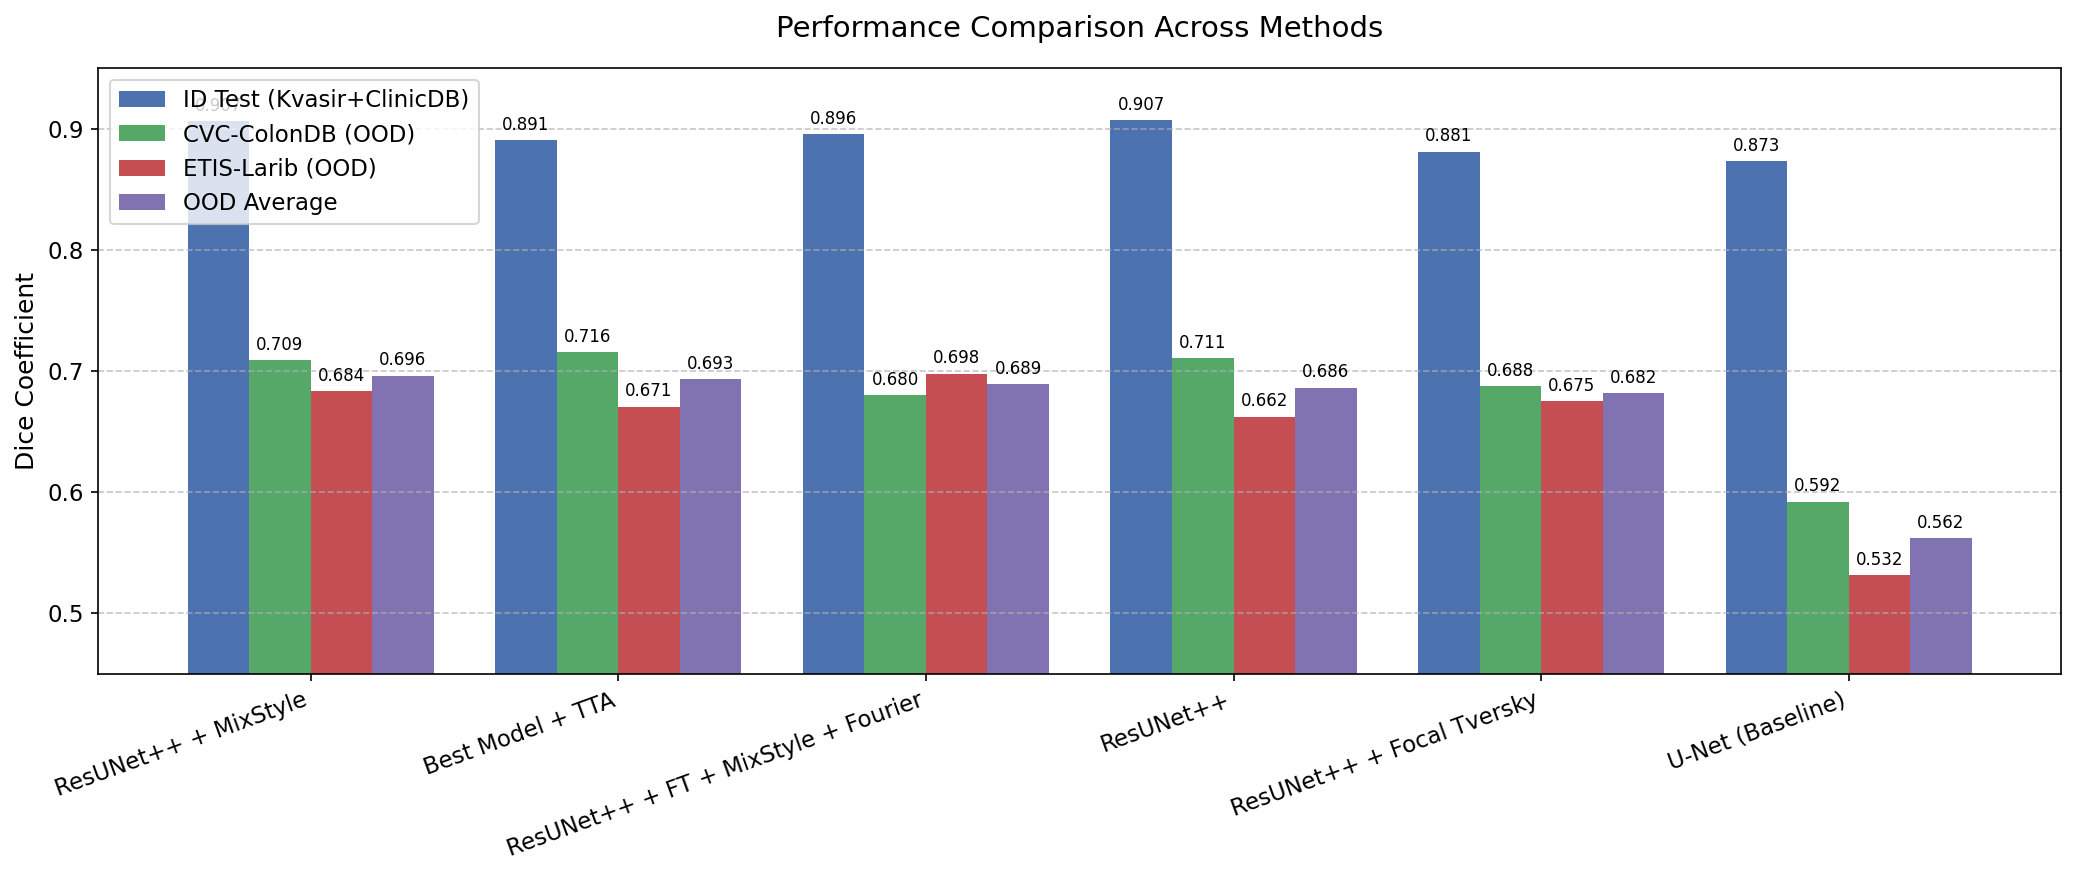

Saved → Fig1_Performance_Comparison.png


In [35]:
plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "figure.dpi": 150
})

methods = df["Method"].tolist()
x = np.arange(len(methods))
width = 0.2

fig, ax = plt.subplots(figsize=(14, 6))

bars1 = ax.bar(x - 1.5*width, df["ID_Dice"], width, label="ID Test (Kvasir+ClinicDB)", color="#4C72B0")
bars2 = ax.bar(x - 0.5*width, df["ColonDB_Dice"], width, label="CVC-ColonDB (OOD)", color="#55A868")
bars3 = ax.bar(x + 0.5*width, df["ETIS_Dice"], width, label="ETIS-Larib (OOD)", color="#C44E52")
bars4 = ax.bar(x + 1.5*width, df["OOD_Avg_Dice"], width, label="OOD Average", color="#8172B2")

ax.set_ylabel("Dice Coefficient")
ax.set_title("Performance Comparison Across Methods", pad=15)
ax.set_xticks(x)
ax.set_xticklabels(methods, rotation=20, ha="right")
ax.set_ylim(0.45, 0.95)
ax.legend(loc="upper left", frameon=True)
ax.grid(axis="y", linestyle="--", alpha=0.7)

# Add value labels
for bars in [bars1, bars2, bars3, bars4]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f"{height:.3f}",
                    xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig("/kaggle/working/Fig1_Performance_Comparison.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved → Fig1_Performance_Comparison.png")

# component wise contribution


In [37]:
# Component contribution (using Exp0 as baseline)
baseline = df[df["Method"] == "U-Net (Baseline)"].iloc[0]

contributions = []

# Architecture (ResUNet++)
resunet = df[df["Method"] == "ResUNet++"].iloc[0]
contributions.append({
    "Component": "Architecture (ResUNet++)",
    "Δ ID Dice": resunet["ID_Dice"] - baseline["ID_Dice"],
    "Δ ColonDB": resunet["ColonDB_Dice"] - baseline["ColonDB_Dice"],
    "Δ ETIS": resunet["ETIS_Dice"] - baseline["ETIS_Dice"],
    "Δ OOD Avg": resunet["OOD_Avg_Dice"] - baseline["OOD_Avg_Dice"]
})

# MixStyle
mixstyle = df[df["Method"] == "ResUNet++ + MixStyle"].iloc[0]
contributions.append({
    "Component": "+ MixStyle",
    "Δ ID Dice": mixstyle["ID_Dice"] - resunet["ID_Dice"],
    "Δ ColonDB": mixstyle["ColonDB_Dice"] - resunet["ColonDB_Dice"],
    "Δ ETIS": mixstyle["ETIS_Dice"] - resunet["ETIS_Dice"],
    "Δ OOD Avg": mixstyle["OOD_Avg_Dice"] - resunet["OOD_Avg_Dice"]
})

# Focal Tversky (alone)
ft = df[df["Method"] == "ResUNet++ + Focal Tversky"].iloc[0]
contributions.append({
    "Component": "+ Focal Tversky (alone)",
    "Δ ID Dice": ft["ID_Dice"] - resunet["ID_Dice"],
    "Δ ColonDB": ft["ColonDB_Dice"] - resunet["ColonDB_Dice"],
    "Δ ETIS": ft["ETIS_Dice"] - resunet["ETIS_Dice"],
    "Δ OOD Avg": ft["OOD_Avg_Dice"] - resunet["OOD_Avg_Dice"]
})

# Fourier + MixStyle + FT
full = df[df["Method"] == "ResUNet++ + FT + MixStyle + Fourier"].iloc[0]
contributions.append({
    "Component": "+ Fourier (on top of MixStyle+FT)",
    "Δ ID Dice": full["ID_Dice"] - mixstyle["ID_Dice"],
    "Δ ColonDB": full["ColonDB_Dice"] - mixstyle["ColonDB_Dice"],
    "Δ ETIS": full["ETIS_Dice"] - mixstyle["ETIS_Dice"],
    "Δ OOD Avg": full["OOD_Avg_Dice"] - mixstyle["OOD_Avg_Dice"]
})

# TTA
tta = df[df["Method"] == "Best Model + TTA"].iloc[0]
contributions.append({
    "Component": "+ TTA (inference)",
    "Δ ID Dice": tta["ID_Dice"] - mixstyle["ID_Dice"],
    "Δ ColonDB": tta["ColonDB_Dice"] - mixstyle["ColonDB_Dice"],
    "Δ ETIS": tta["ETIS_Dice"] - mixstyle["ETIS_Dice"],
    "Δ OOD Avg": tta["OOD_Avg_Dice"] - mixstyle["OOD_Avg_Dice"]
})

contrib_df = pd.DataFrame(contributions)
contrib_df = contrib_df.round(4)

print("="*90)
print("TABLE 2: Component-wise Contribution Analysis (Δ Dice)")
print("="*90)
print(contrib_df.to_string(index=False))

contrib_df.to_csv("/kaggle/working/Table2_Component_Contribution.csv", index=False)
print("\nSaved → Table2_Component_Contribution.csv")

TABLE 2: Component-wise Contribution Analysis (Δ Dice)
                        Component  Δ ID Dice  Δ ColonDB  Δ ETIS  Δ OOD Avg
         Architecture (ResUNet++)     0.0342     0.1183  0.1307     0.1245
                       + MixStyle    -0.0009    -0.0017  0.0213     0.0098
          + Focal Tversky (alone)    -0.0261    -0.0228  0.0130    -0.0049
+ Fourier (on top of MixStyle+FT)    -0.0109    -0.0286  0.0143    -0.0072
                + TTA (inference)    -0.0157     0.0069 -0.0130    -0.0030

Saved → Table2_Component_Contribution.csv


# Component Contribution Bar Plot

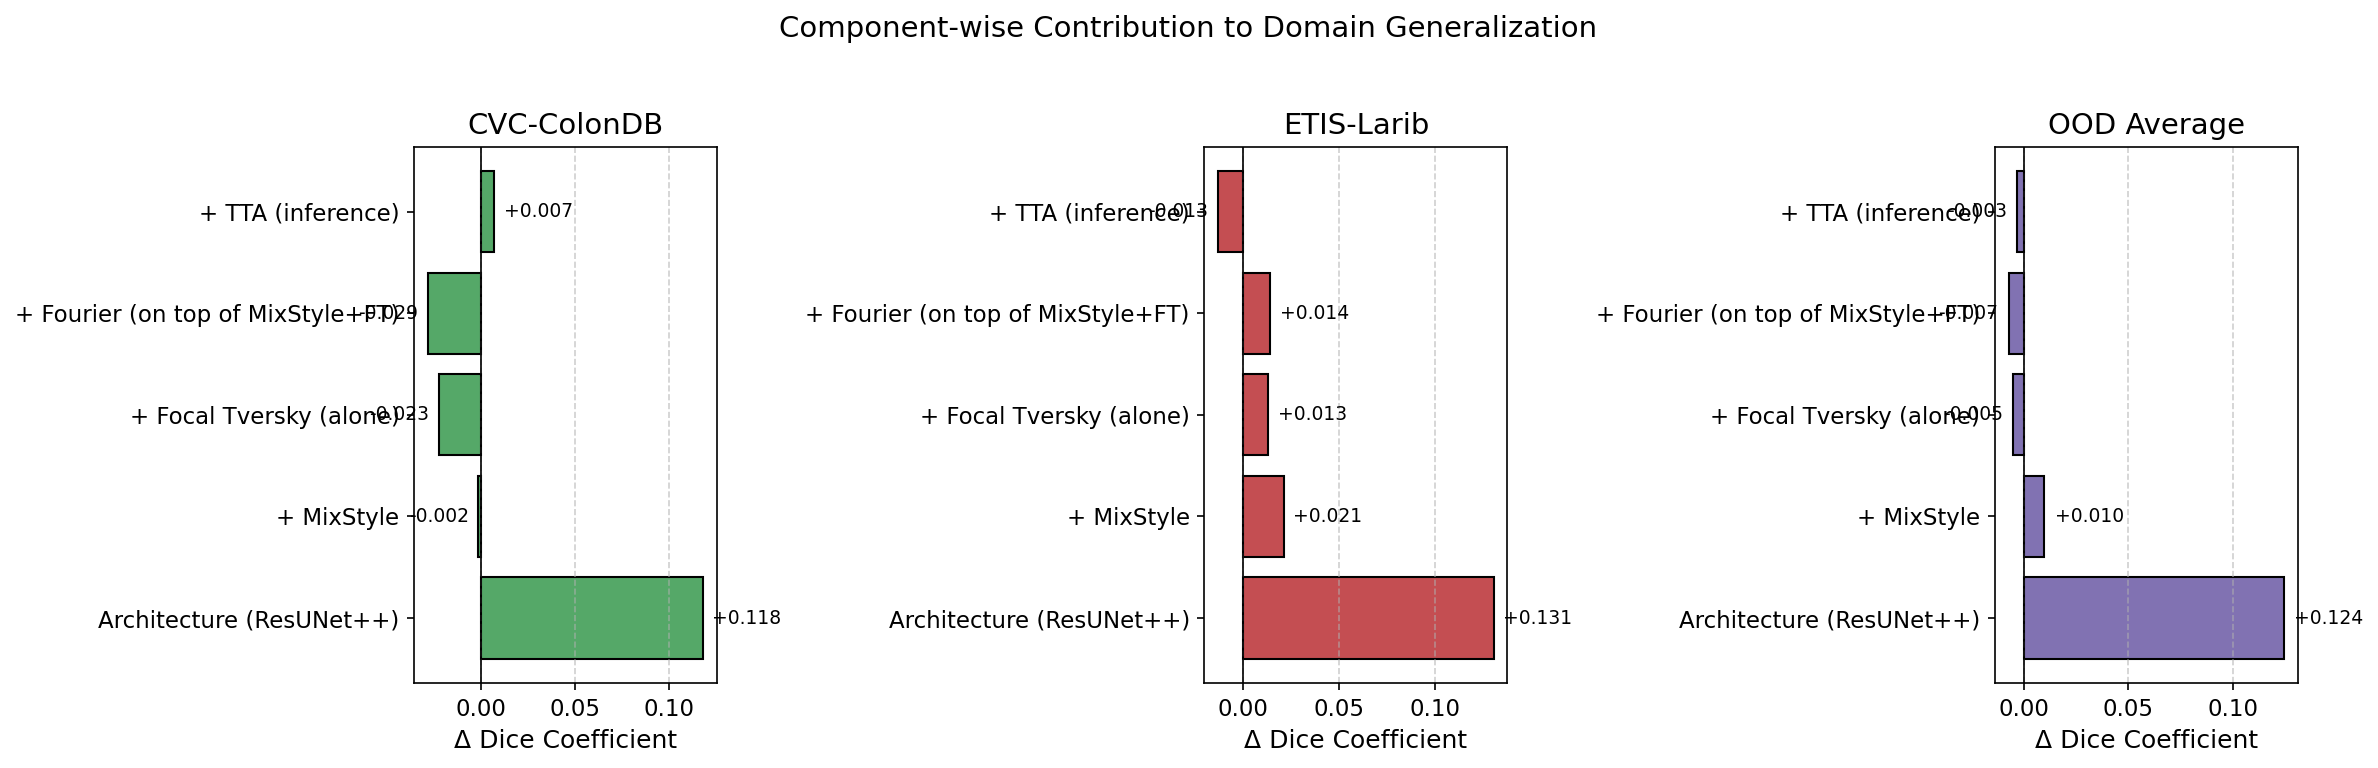

Saved → Fig2_Component_Contribution.png


In [38]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = ["Δ ColonDB", "Δ ETIS", "Δ OOD Avg"]
titles = ["CVC-ColonDB", "ETIS-Larib", "OOD Average"]
colors = ["#55A868", "#C44E52", "#8172B2"]

for ax, metric, title, color in zip(axes, metrics, titles, colors):
    vals = contrib_df[metric].values
    bars = ax.barh(contrib_df["Component"], vals, color=color, edgecolor="black")
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(title)
    ax.set_xlabel("Δ Dice Coefficient")
    ax.grid(axis="x", linestyle="--", alpha=0.6)
    
    for bar, val in zip(bars, vals):
        ax.text(val + (0.005 if val >= 0 else -0.005), 
                bar.get_y() + bar.get_height()/2,
                f"{val:+.3f}", va="center", 
                ha="left" if val >= 0 else "right", fontsize=9)

plt.suptitle("Component-wise Contribution to Domain Generalization", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("/kaggle/working/Fig2_Component_Contribution.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved → Fig2_Component_Contribution.png")

# Qualitative Visualization (Best Model)

In [39]:
# ========== Qualitative Results ==========
# Load the best model (Experiment 2)
best_model_path = "/kaggle/working/best_exp2_ResUNet++_BCE_Dice_MixStyle.pth"

model = get_model(EXPERIMENT_CONFIG[2])   # or recreate the model
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
model.eval()

def show_predictions(image_dir, mask_dir, title, num_samples=4):
    images = sorted(list(Path(image_dir).glob("*.jpg")) + list(Path(image_dir).glob("*.png")))
    masks  = sorted(list(Path(mask_dir).glob("*.jpg")) + list(Path(mask_dir).glob("*.png")))
    
    indices = np.linspace(0, len(images)-1, num_samples, dtype=int)
    
    fig, axes = plt.subplots(num_samples, 3, figsize=(12, 3.5*num_samples))
    if num_samples == 1:
        axes = axes.reshape(1, -1)
    
    for i, idx in enumerate(indices):
        img = cv2.imread(str(images[idx]))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(str(masks[idx]), cv2.IMREAD_GRAYSCALE)
        mask = (mask > 127).astype(np.float32)
        
        # Predict
        transformed = val_transform(image=img, mask=mask)
        img_t = transformed["image"].unsqueeze(0).to(DEVICE)
        
        with torch.no_grad():
            pred = torch.sigmoid(model(img_t)).squeeze().cpu().numpy()
        pred_bin = (pred > 0.5).astype(np.float32)
        
        # Resize original for display
        img_disp = cv2.resize(img, (256, 256))
        mask_disp = cv2.resize(mask, (256, 256))
        
        axes[i, 0].imshow(img_disp)
        axes[i, 0].set_title("Image" if i == 0 else "")
        axes[i, 0].axis("off")
        
        axes[i, 1].imshow(mask_disp, cmap="gray")
        axes[i, 1].set_title("Ground Truth" if i == 0 else "")
        axes[i, 1].axis("off")
        
        axes[i, 2].imshow(pred_bin, cmap="gray")
        axes[i, 2].set_title("Prediction" if i == 0 else "")
        axes[i, 2].axis("off")
    
    plt.suptitle(title, fontsize=14, y=1.01)
    plt.tight_layout()
    return fig

# Generate qualitative figures
fig1 = show_predictions(COLON_IMG, COLON_MASK, "Qualitative Results on CVC-ColonDB (OOD)", num_samples=3)
plt.savefig("/kaggle/working/Fig3_Qualitative_ColonDB.png", dpi=300, bbox_inches="tight")
plt.show()

fig2 = show_predictions(ETIS_IMG, ETIS_MASK, "Qualitative Results on ETIS-Larib (OOD)", num_samples=3)
plt.savefig("/kaggle/working/Fig4_Qualitative_ETIS.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved → Fig3_Qualitative_ColonDB.png")
print("Saved → Fig4_Qualitative_ETIS.png")

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/working/best_exp2_ResUNet++_BCE_Dice_MixStyle.pth'

# Dataset Analysis

Analyzing datasets... (this may take 1-2 minutes)


Kvasir-SEG:   0%|          | 0/1000 [00:00<?, ?it/s]

CVC-ClinicDB:   0%|          | 0/612 [00:00<?, ?it/s]

CVC-ColonDB:   0%|          | 0/380 [00:00<?, ?it/s]

ETIS-Larib:   0%|          | 0/196 [00:00<?, ?it/s]


Total images analyzed: 2188
dataset
Kvasir-SEG      1000
CVC-ClinicDB     612
CVC-ColonDB      380
ETIS-Larib       196
Name: count, dtype: int64

DATASET SUMMARY
              n_images  mean_height  mean_width  mean_polyp_ratio  median_polyp_ratio  max_polyp_ratio  mean_intensity  std_intensity    mean_R    mean_G   mean_B
dataset                                                                                                                                                           
CVC-ClinicDB       612      288.000     384.000            0.0917              0.0683           0.4896         76.1952        54.1663  102.2053   68.7038  46.9490
CVC-ColonDB        380      500.000     574.000            0.0745              0.0362           0.6315         82.0519        58.7790  112.5120   73.1928  47.8963
ETIS-Larib         196      966.000    1225.000            0.0453              0.0198           0.2905        121.1854        54.6328  153.3712  109.9551  94.9257
Kvasir-SEG        100

/tmp/ipykernel_58/4253393423.py:129: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="dataset", y="polyp_ratio", palette="Set2")


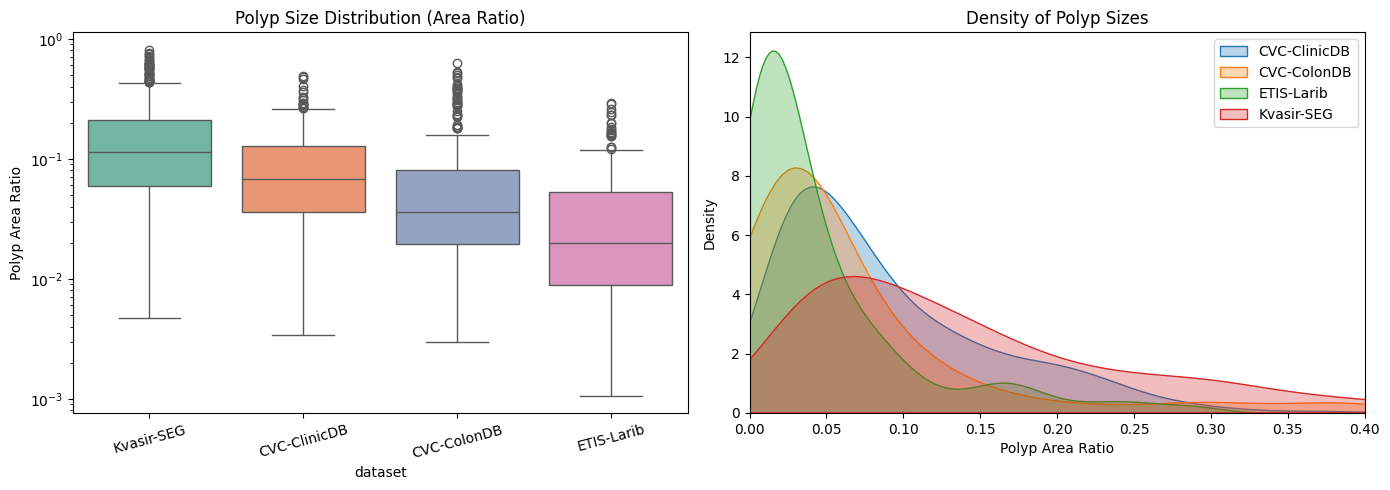

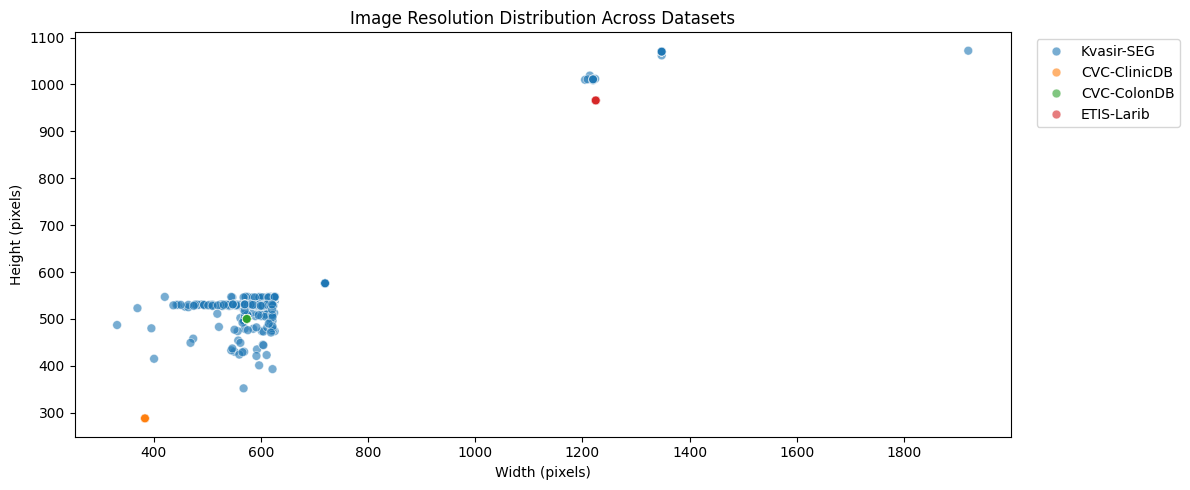

/tmp/ipykernel_58/4253393423.py:168: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="dataset", y="mean_intensity", ax=axes[0], palette="Set2")
/tmp/ipykernel_58/4253393423.py:173: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="dataset", y="mean_R", ax=axes[1], palette="Set2")
/tmp/ipykernel_58/4253393423.py:178: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="dataset", y="mean_G", ax=axes[2], palette="Set2")


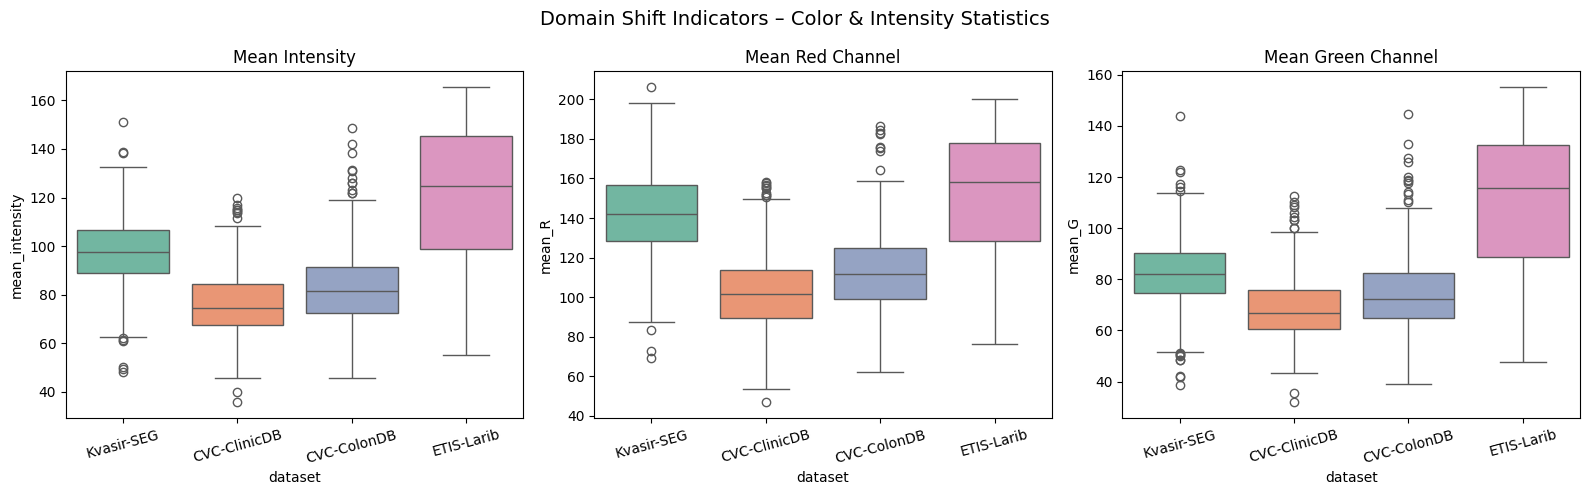

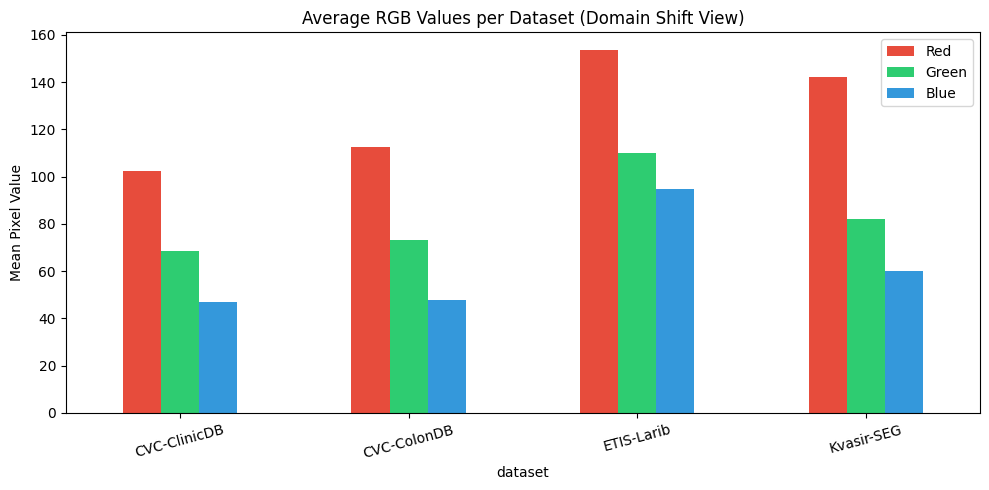


CLASS IMBALANCE (Polyp vs Background)
CVC-ClinicDB         → Average polyp pixels: 9.17%   |   Background: 90.83%
CVC-ColonDB          → Average polyp pixels: 7.45%   |   Background: 92.55%
ETIS-Larib           → Average polyp pixels: 4.53%   |   Background: 95.47%
Kvasir-SEG           → Average polyp pixels: 15.39%   |   Background: 84.61%

Generating sample visualizations...


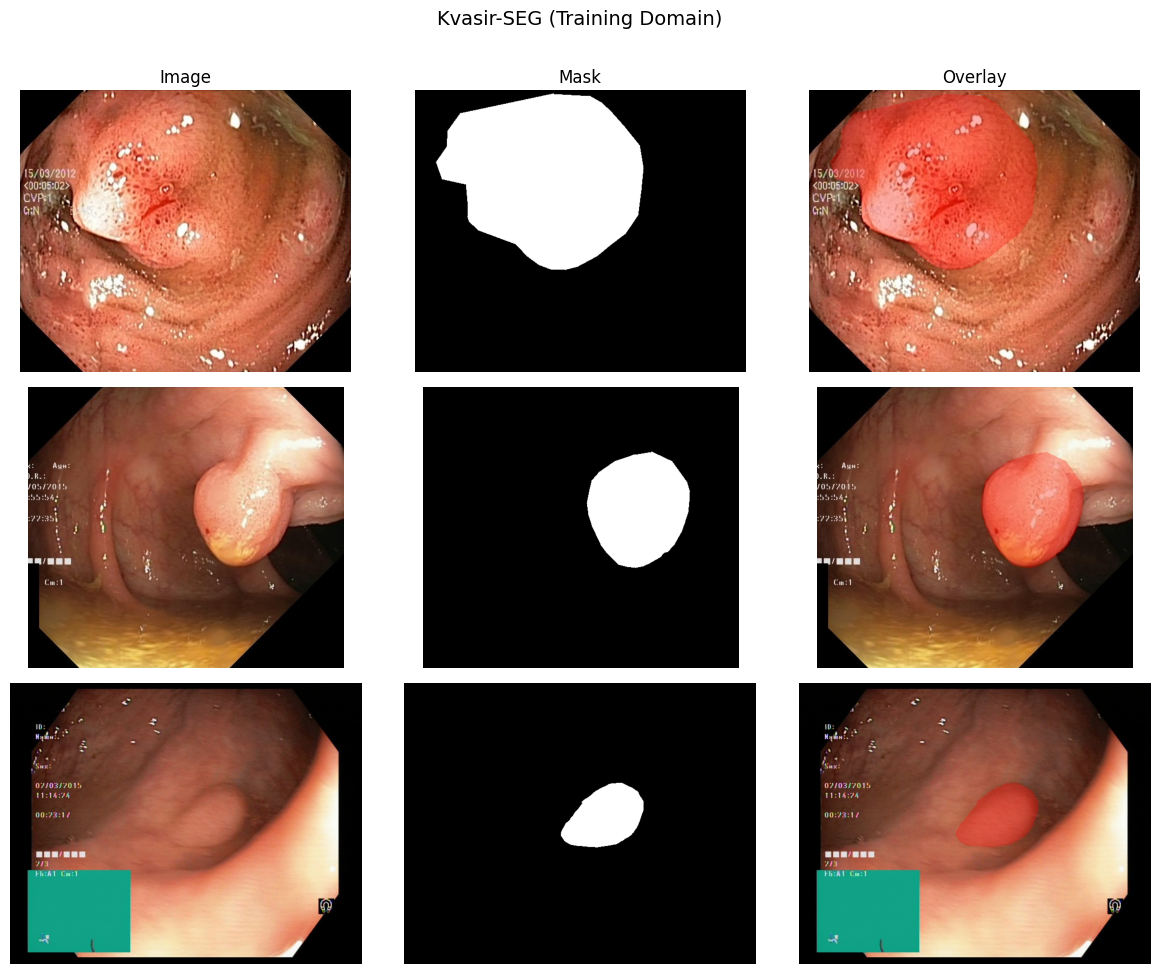

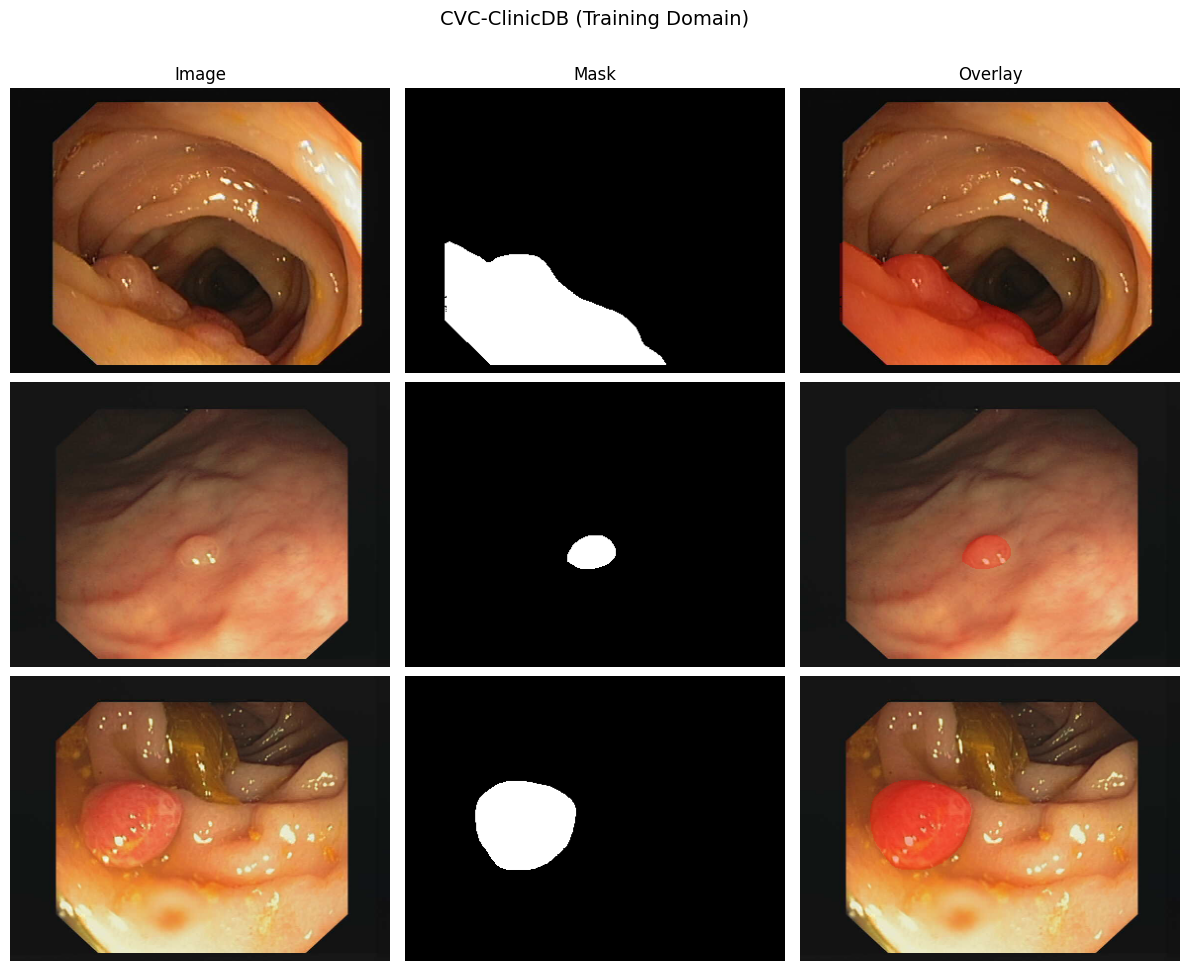

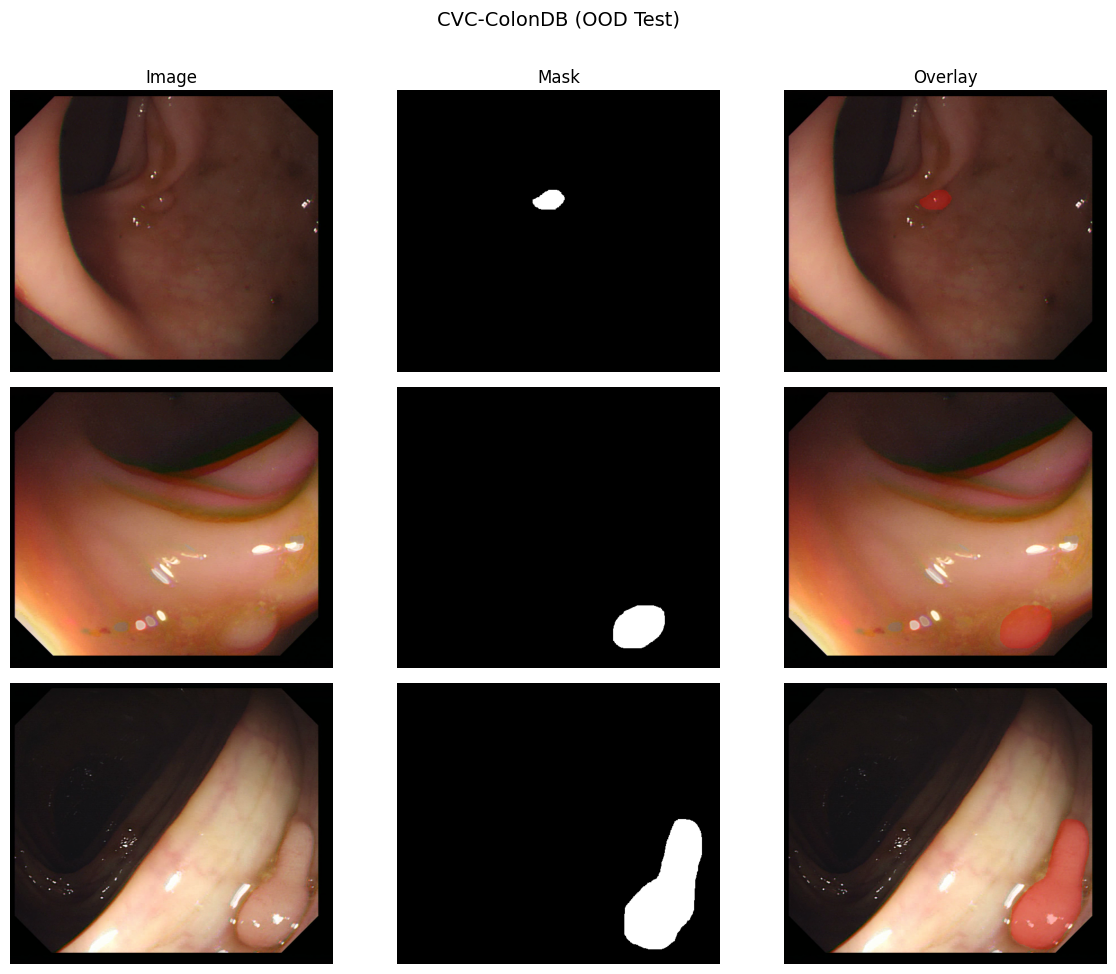

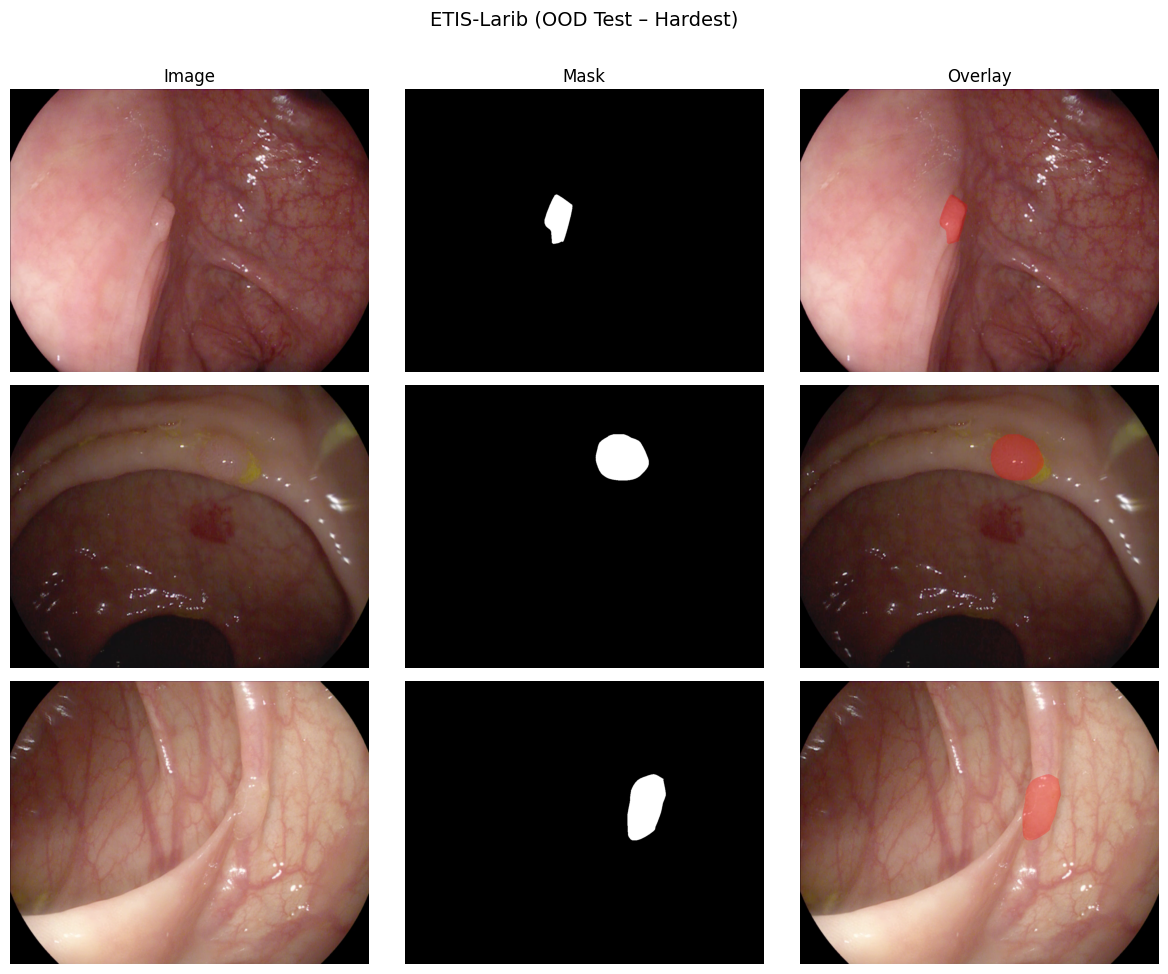


KEY DATASET INSIGHTS

1. Class Imbalance: Polyps occupy only ~3–8% of the image on average → 
   justifies the use of Dice / Tversky losses.

2. Domain Shift exists:
   - Different mean intensity and RGB statistics between source (Kvasir+Clinic) 
     and target (ColonDB, ETIS).
   - This is why MixStyle and Fourier Amplitude Mixing are relevant.

3. Resolution varies significantly across datasets → 
   resizing to 256×256 is necessary and already done.

4. ETIS has the most challenging small polyps (lowest average polyp ratio).

5. Training set size (~1612 images) is reasonable for a ResNet-34 based model.

All analysis figures and CSV saved to /kaggle/working/


In [1]:
# ============================================================
# DEEP DATASET ANALYSIS – Polyp Segmentation
# Kvasir-SEG + CVC-ClinicDB (Train) | CVC-ColonDB + ETIS (OOD)
# ============================================================

import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm.auto import tqdm
from collections import defaultdict

# ---------- Paths (use the ones that already work for you) ----------
ROOT = Path("/kaggle/input/datasets")

KVASIR_IMG  = ROOT / "debeshjha1" / "kvasirseg" / "Kvasir-SEG" / "Kvasir-SEG" / "images"
KVASIR_MASK = ROOT / "debeshjha1" / "kvasirseg" / "Kvasir-SEG" / "Kvasir-SEG" / "masks"

CLINIC_IMG  = ROOT / "balraj98" / "cvcclinicdb" / "PNG" / "Original"
CLINIC_MASK = ROOT / "balraj98" / "cvcclinicdb" / "PNG" / "Ground Truth"

COLON_IMG   = ROOT / "nourabentaher" / "cvc-colondb" / "CVC-ColonDB" / "images"
COLON_MASK  = ROOT / "nourabentaher" / "cvc-colondb" / "CVC-ColonDB" / "masks"

ETIS_IMG    = ROOT / "nguyenvoquocduong" / "etis-laribpolypdb" / "images"
ETIS_MASK   = ROOT / "nguyenvoquocduong" / "etis-laribpolypdb" / "masks"

# ============================================================
# 1. Collect basic statistics
# ============================================================

def analyze_dataset(name, img_dir, mask_dir):
    img_paths  = sorted(list(Path(img_dir).glob("*.*")))
    mask_paths = sorted(list(Path(mask_dir).glob("*.*")))
    
    # Keep only common extensions
    img_paths  = [p for p in img_paths  if p.suffix.lower() in [".jpg", ".jpeg", ".png", ".tif", ".tiff"]]
    mask_paths = [p for p in mask_paths if p.suffix.lower() in [".jpg", ".jpeg", ".png", ".tif", ".tiff"]]
    
    records = []
    
    for img_p, mask_p in tqdm(zip(img_paths, mask_paths), total=len(img_paths), desc=name):
        img  = cv2.imread(str(img_p))
        mask = cv2.imread(str(mask_p), cv2.IMREAD_GRAYSCALE)
        
        if img is None or mask is None:
            continue
            
        h, w = img.shape[:2]
        mask_bin = (mask > 127).astype(np.uint8)
        
        polyp_area = mask_bin.sum()
        total_area = h * w
        polyp_ratio = polyp_area / total_area
        
        # Color statistics (domain shift indicators)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mean_r, mean_g, mean_b = img_rgb.mean(axis=(0,1))
        std_r,  std_g,  std_b  = img_rgb.std(axis=(0,1))
        
        # Intensity
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        mean_intensity = gray.mean()
        std_intensity  = gray.std()
        
        records.append({
            "dataset": name,
            "height": h,
            "width": w,
            "aspect_ratio": w / h,
            "polyp_pixels": polyp_area,
            "polyp_ratio": polyp_ratio,
            "mean_R": mean_r, "mean_G": mean_g, "mean_B": mean_b,
            "std_R": std_r,   "std_G": std_g,   "std_B": std_b,
            "mean_intensity": mean_intensity,
            "std_intensity": std_intensity,
            "has_polyp": polyp_area > 0
        })
    
    return pd.DataFrame(records)

print("Analyzing datasets... (this may take 1-2 minutes)")

df_kvasir = analyze_dataset("Kvasir-SEG", KVASIR_IMG, KVASIR_MASK)
df_clinic = analyze_dataset("CVC-ClinicDB", CLINIC_IMG, CLINIC_MASK)
df_colon  = analyze_dataset("CVC-ColonDB", COLON_IMG, COLON_MASK)
df_etis   = analyze_dataset("ETIS-Larib", ETIS_IMG, ETIS_MASK)

df = pd.concat([df_kvasir, df_clinic, df_colon, df_etis], ignore_index=True)
print("\nTotal images analyzed:", len(df))
print(df["dataset"].value_counts())

# ============================================================
# 2. Summary Table
# ============================================================

summary = df.groupby("dataset").agg(
    n_images          = ("dataset", "count"),
    mean_height       = ("height", "mean"),
    mean_width        = ("width", "mean"),
    mean_polyp_ratio  = ("polyp_ratio", "mean"),
    median_polyp_ratio= ("polyp_ratio", "median"),
    max_polyp_ratio   = ("polyp_ratio", "max"),
    mean_intensity    = ("mean_intensity", "mean"),
    std_intensity     = ("std_intensity", "mean"),
    mean_R            = ("mean_R", "mean"),
    mean_G            = ("mean_G", "mean"),
    mean_B            = ("mean_B", "mean"),
).round(4)

print("\n" + "="*90)
print("DATASET SUMMARY")
print("="*90)
print(summary.to_string())

summary.to_csv("/kaggle/working/dataset_summary.csv")
print("\nSaved → dataset_summary.csv")

# ============================================================
# 3. Polyp Size Distribution (Class Imbalance)
# ============================================================

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.boxplot(data=df, x="dataset", y="polyp_ratio", palette="Set2")
plt.xticks(rotation=15)
plt.ylabel("Polyp Area Ratio")
plt.title("Polyp Size Distribution (Area Ratio)")
plt.yscale("log")          # log scale because most polyps are small

plt.subplot(1, 2, 2)
for name, group in df.groupby("dataset"):
    sns.kdeplot(group["polyp_ratio"], label=name, fill=True, alpha=0.3)
plt.xlabel("Polyp Area Ratio")
plt.title("Density of Polyp Sizes")
plt.legend()
plt.xlim(0, 0.4)

plt.tight_layout()
plt.savefig("/kaggle/working/Fig_Polyp_Size_Distribution.png", dpi=200, bbox_inches="tight")
plt.show()

# ============================================================
# 4. Image Resolution Distribution
# ============================================================

plt.figure(figsize=(12, 5))
sns.scatterplot(data=df, x="width", y="height", hue="dataset", alpha=0.6, s=40)
plt.title("Image Resolution Distribution Across Datasets")
plt.xlabel("Width (pixels)")
plt.ylabel("Height (pixels)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("/kaggle/working/Fig_Resolution_Distribution.png", dpi=200, bbox_inches="tight")
plt.show()

# ============================================================
# 5. Domain Shift – Color / Intensity Statistics
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Mean Intensity
sns.boxplot(data=df, x="dataset", y="mean_intensity", ax=axes[0], palette="Set2")
axes[0].set_title("Mean Intensity")
axes[0].tick_params(axis='x', rotation=15)

# Mean Red channel
sns.boxplot(data=df, x="dataset", y="mean_R", ax=axes[1], palette="Set2")
axes[1].set_title("Mean Red Channel")
axes[1].tick_params(axis='x', rotation=15)

# Mean Green channel
sns.boxplot(data=df, x="dataset", y="mean_G", ax=axes[2], palette="Set2")
axes[2].set_title("Mean Green Channel")
axes[2].tick_params(axis='x', rotation=15)

plt.suptitle("Domain Shift Indicators – Color & Intensity Statistics", fontsize=14)
plt.tight_layout()
plt.savefig("/kaggle/working/Fig_Domain_Shift_Color.png", dpi=200, bbox_inches="tight")
plt.show()

# ============================================================
# 6. RGB Mean Comparison (Train vs OOD)
# ============================================================

rgb_means = df.groupby("dataset")[["mean_R", "mean_G", "mean_B"]].mean()

fig, ax = plt.subplots(figsize=(10, 5))
rgb_means.plot(kind="bar", ax=ax, color=["#e74c3c", "#2ecc71", "#3498db"])
ax.set_title("Average RGB Values per Dataset (Domain Shift View)")
ax.set_ylabel("Mean Pixel Value")
ax.tick_params(axis='x', rotation=15)
ax.legend(["Red", "Green", "Blue"])
plt.tight_layout()
plt.savefig("/kaggle/working/Fig_RGB_Means.png", dpi=200, bbox_inches="tight")
plt.show()

# ============================================================
# 7. Class Imbalance Numbers
# ============================================================

print("\n" + "="*90)
print("CLASS IMBALANCE (Polyp vs Background)")
print("="*90)

for name, group in df.groupby("dataset"):
    avg_polyp = group["polyp_ratio"].mean() * 100
    print(f"{name:20s} → Average polyp pixels: {avg_polyp:.2f}%   |   Background: {100-avg_polyp:.2f}%")

# ============================================================
# 8. Sample Visualization (4 datasets × 3 samples)
# ============================================================

def show_samples(img_dir, mask_dir, title, n=3):
    img_paths  = sorted([p for p in Path(img_dir).glob("*.*") if p.suffix.lower() in [".jpg",".png",".tif",".tiff"]])
    mask_paths = sorted([p for p in Path(mask_dir).glob("*.*") if p.suffix.lower() in [".jpg",".png",".tif",".tiff"]])
    
    indices = np.linspace(0, len(img_paths)-1, n, dtype=int)
    
    fig, axes = plt.subplots(n, 3, figsize=(12, 3.2*n))
    if n == 1:
        axes = axes.reshape(1, -1)
    
    for i, idx in enumerate(indices):
        img  = cv2.cvtColor(cv2.imread(str(img_paths[idx])), cv2.COLOR_BGR2RGB)
        mask = cv2.imread(str(mask_paths[idx]), cv2.IMREAD_GRAYSCALE)
        mask = (mask > 127).astype(np.uint8) * 255
        
        # Overlay
        overlay = img.copy()
        overlay[mask > 0] = [255, 0, 0]          # red overlay
        blended = cv2.addWeighted(img, 0.7, overlay, 0.3, 0)
        
        axes[i,0].imshow(img)
        axes[i,0].set_title("Image" if i==0 else "")
        axes[i,0].axis("off")
        
        axes[i,1].imshow(mask, cmap="gray")
        axes[i,1].set_title("Mask" if i==0 else "")
        axes[i,1].axis("off")
        
        axes[i,2].imshow(blended)
        axes[i,2].set_title("Overlay" if i==0 else "")
        axes[i,2].axis("off")
    
    plt.suptitle(title, fontsize=14, y=1.01)
    plt.tight_layout()
    return fig

print("\nGenerating sample visualizations...")

fig1 = show_samples(KVASIR_IMG, KVASIR_MASK, "Kvasir-SEG (Training Domain)", n=3)
plt.savefig("/kaggle/working/Fig_Samples_Kvasir.png", dpi=150, bbox_inches="tight")
plt.show()

fig2 = show_samples(CLINIC_IMG, CLINIC_MASK, "CVC-ClinicDB (Training Domain)", n=3)
plt.savefig("/kaggle/working/Fig_Samples_ClinicDB.png", dpi=150, bbox_inches="tight")
plt.show()

fig3 = show_samples(COLON_IMG, COLON_MASK, "CVC-ColonDB (OOD Test)", n=3)
plt.savefig("/kaggle/working/Fig_Samples_ColonDB.png", dpi=150, bbox_inches="tight")
plt.show()

fig4 = show_samples(ETIS_IMG, ETIS_MASK, "ETIS-Larib (OOD Test – Hardest)", n=3)
plt.savefig("/kaggle/working/Fig_Samples_ETIS.png", dpi=150, bbox_inches="tight")
plt.show()

# ============================================================
# 9. Final Key Insights (printed)
# ============================================================

print("\n" + "="*90)
print("KEY DATASET INSIGHTS")
print("="*90)
print("""
1. Class Imbalance: Polyps occupy only ~3–8% of the image on average → 
   justifies the use of Dice / Tversky losses.

2. Domain Shift exists:
   - Different mean intensity and RGB statistics between source (Kvasir+Clinic) 
     and target (ColonDB, ETIS).
   - This is why MixStyle and Fourier Amplitude Mixing are relevant.

3. Resolution varies significantly across datasets → 
   resizing to 256×256 is necessary and already done.

4. ETIS has the most challenging small polyps (lowest average polyp ratio).

5. Training set size (~1612 images) is reasonable for a ResNet-34 based model.
""")

print("All analysis figures and CSV saved to /kaggle/working/")

# Experiment 6 – Full Combined High-Performance Cell

In [26]:
# ============================================================
# EXPERIMENT 6 – FULL COMBINED HIGH-PERFORMANCE (FIXED)
# Self-contained version (works even after kernel restart)
# ============================================================

import os
import random
import numpy as np
import pandas as pd
import cv2
from pathlib import Path
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp

# -----------------------------
# Reproducibility
# -----------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# -----------------------------
# Paths
# -----------------------------
ROOT = Path("/kaggle/input/datasets")

KVASIR_IMG  = ROOT / "debeshjha1" / "kvasirseg" / "Kvasir-SEG" / "Kvasir-SEG" / "images"
KVASIR_MASK = ROOT / "debeshjha1" / "kvasirseg" / "Kvasir-SEG" / "Kvasir-SEG" / "masks"
CLINIC_IMG  = ROOT / "balraj98" / "cvcclinicdb" / "PNG" / "Original"
CLINIC_MASK = ROOT / "balraj98" / "cvcclinicdb" / "PNG" / "Ground Truth"
COLON_IMG   = ROOT / "nourabentaher" / "cvc-colondb" / "CVC-ColonDB" / "images"
COLON_MASK  = ROOT / "nourabentaher" / "cvc-colondb" / "CVC-ColonDB" / "masks"
ETIS_IMG    = ROOT / "nguyenvoquocduong" / "etis-laribpolypdb" / "images"
ETIS_MASK   = ROOT / "nguyenvoquocduong" / "etis-laribpolypdb" / "masks"

# -----------------------------
# Create training lists
# -----------------------------
train_images = sorted(list(KVASIR_IMG.glob("*")) + list(CLINIC_IMG.glob("*")))
train_masks  = sorted(list(KVASIR_MASK.glob("*")) + list(CLINIC_MASK.glob("*")))

print(f"Total training pairs: {len(train_images)}")
assert len(train_images) == len(train_masks), "Image-Mask count mismatch!"

from sklearn.model_selection import train_test_split
train_idx, temp_idx = train_test_split(range(len(train_images)), test_size=0.2, random_state=SEED)
val_idx, id_test_idx = train_test_split(temp_idx, test_size=0.5, random_state=SEED)

print(f"Train: {len(train_idx)} | Val: {len(val_idx)} | ID-Test: {len(id_test_idx)}")

# -----------------------------
# Config
# -----------------------------
EXPERIMENT_ID = 6
cfg = {
    "name": "Full_Combined_HighPerf",
    "backbone": "resunetpp",
    "loss": "bce_dice",
    "mixstyle": True,
    "fourier": True,
    "tta": True
}
print(f"▶ Running Experiment [6]: {cfg['name']}")

# -----------------------------
# Transforms (fixed GaussNoise)
# -----------------------------
IMG_SIZE = 256

train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.12, scale_limit=0.18, rotate_limit=25, p=0.6),
    A.OneOf([
        A.RandomBrightnessContrast(brightness_limit=0.25, contrast_limit=0.25, p=1.0),
        A.HueSaturationValue(hue_shift_limit=15, sat_shift_limit=25, val_shift_limit=20, p=1.0),
        A.CLAHE(clip_limit=3.0, p=1.0),
    ], p=0.5),
    A.GaussNoise(std_range=(0.02, 0.08), p=0.25),   # <-- FIXED
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

# -----------------------------
# Mild Fourier
# -----------------------------
def fourier_amplitude_mix(img1, img2, alpha=0.4, low_freq_ratio=0.08):
    h, w = img1.shape[:2]
    img2 = cv2.resize(img2, (w, h), interpolation=cv2.INTER_LINEAR)
    img1 = img1.astype(np.float32)
    img2 = img2.astype(np.float32)

    fft1 = np.fft.fft2(img1, axes=(0, 1))
    fft2 = np.fft.fft2(img2, axes=(0, 1))
    amp1, phase1 = np.abs(fft1), np.angle(fft1)
    amp2 = np.abs(fft2)

    ch, cw = h // 2, w // 2
    rh = max(1, int(h * low_freq_ratio))
    rw = max(1, int(w * low_freq_ratio))

    amp_mixed = amp1.copy()
    amp_mixed[ch-rh:ch+rh, cw-rw:cw+rw] = (
        alpha * amp1[ch-rh:ch+rh, cw-rw:cw+rw] +
        (1 - alpha) * amp2[ch-rh:ch+rh, cw-rw:cw+rw]
    )
    mixed = np.fft.ifft2(amp_mixed * np.exp(1j * phase1), axes=(0, 1)).real
    return np.clip(mixed, 0, 255).astype(np.uint8)

# -----------------------------
# Dataset
# -----------------------------
class PolypDataset(Dataset):
    def __init__(self, image_paths, mask_paths, indices, transform=None, fourier=False):
        self.image_paths = [image_paths[i] for i in indices]
        self.mask_paths  = [mask_paths[i] for i in indices]
        self.transform = transform
        self.fourier = fourier

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = cv2.imread(str(self.image_paths[idx]))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(str(self.mask_paths[idx]), cv2.IMREAD_GRAYSCALE)
        mask = (mask > 127).astype(np.float32)

        if self.fourier and random.random() < 0.35:
            other_idx = random.randint(0, len(self)-1)
            img2 = cv2.imread(str(self.image_paths[other_idx]))
            img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
            img = fourier_amplitude_mix(img, img2, alpha=random.uniform(0.25, 0.55))

        if self.transform:
            augmented = self.transform(image=img, mask=mask)
            img = augmented["image"]
            mask = augmented["mask"].unsqueeze(0)
        return img, mask

# -----------------------------
# DataLoaders
# -----------------------------
BATCH_SIZE = 8
train_ds = PolypDataset(train_images, train_masks, train_idx, transform=train_transform, fourier=True)
val_ds   = PolypDataset(train_images, train_masks, val_idx,   transform=val_transform,  fourier=False)
id_test_ds = PolypDataset(train_images, train_masks, id_test_idx, transform=val_transform, fourier=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
id_test_loader = DataLoader(id_test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

# -----------------------------
# MixStyle + Model
# -----------------------------
class MixStyle(nn.Module):
    def __init__(self, p=0.5, alpha=0.1, eps=1e-6):
        super().__init__()
        self.p = p
        self.alpha = alpha
        self.eps = eps

    def forward(self, x):
        if not self.training or random.random() > self.p:
            return x
        B = x.size(0)
        mu = x.mean(dim=[2, 3], keepdim=True)
        var = x.var(dim=[2, 3], keepdim=True)
        sig = (var + self.eps).sqrt()
        mu, sig = mu.detach(), sig.detach()
        x_normed = (x - mu) / sig
        lmda = torch.distributions.Beta(self.alpha, self.alpha).sample((B, 1, 1, 1)).to(x.device)
        perm = torch.randperm(B)
        mu2, sig2 = mu[perm], sig[perm]
        mu_mix = mu * lmda + mu2 * (1 - lmda)
        sig_mix = sig * lmda + sig2 * (1 - lmda)
        return x_normed * sig_mix + mu_mix

model = smp.UnetPlusPlus(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
    activation=None,
    decoder_attention_type="scse"
)
model.encoder.layer1 = nn.Sequential(model.encoder.layer1, MixStyle(p=0.5))
model.encoder.layer2 = nn.Sequential(model.encoder.layer2, MixStyle(p=0.5))
model = model.to(DEVICE)
print(f"Model parameters: {sum(p.numel() for p in model.parameters())/1e6:.2f} M")

# -----------------------------
# Loss & Metrics
# -----------------------------
class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth
    def forward(self, logits, targets):
        probs = torch.sigmoid(logits).view(-1)
        targets = targets.view(-1)
        intersection = (probs * targets).sum()
        return 1 - (2. * intersection + self.smooth) / (probs.sum() + targets.sum() + self.smooth)

class BCEDiceLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.dice = DiceLoss()
    def forward(self, logits, targets):
        return self.bce(logits, targets) + self.dice(logits, targets)

criterion = BCEDiceLoss()

def dice_coef(preds, targets, threshold=0.5):
    preds = (torch.sigmoid(preds) > threshold).float().view(-1)
    targets = targets.view(-1)
    intersection = (preds * targets).sum()
    return (2. * intersection) / (preds.sum() + targets.sum() + 1e-8)

def iou_score(preds, targets, threshold=0.5):
    preds = (torch.sigmoid(preds) > threshold).float().view(-1)
    targets = targets.view(-1)
    intersection = (preds * targets).sum()
    union = preds.sum() + targets.sum() - intersection
    return intersection / (union + 1e-8)

# -----------------------------
# Training
# -----------------------------
EPOCHS = 60
LR = 8e-5

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

best_dice = 0.0
save_path = "/kaggle/working/best_exp6_Full_Combined_HighPerf.pth"

print(f"\nStarting training for {EPOCHS} epochs...\n")

for epoch in range(1, EPOCHS+1):
    model.train()
    total_loss = 0
    for images, masks in tqdm(train_loader, desc=f"Epoch {epoch:02d} Train", leave=False):
        images, masks = images.to(DEVICE), masks.to(DEVICE)
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, masks)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    train_loss = total_loss / len(train_loader)

    model.eval()
    val_loss, dice, iou = 0, 0, 0
    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(DEVICE), masks.to(DEVICE)
            logits = model(images)
            val_loss += criterion(logits, masks).item()
            dice += dice_coef(logits, masks).item()
            iou  += iou_score(logits, masks).item()
    n = len(val_loader)
    val_loss, val_dice, val_iou = val_loss/n, dice/n, iou/n
    scheduler.step()

    print(f"Epoch {epoch:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Dice: {val_dice:.4f} | IoU: {val_iou:.4f}")

    if val_dice > best_dice:
        best_dice = val_dice
        torch.save(model.state_dict(), save_path)
        print(f"  → Saved best model (Dice={best_dice:.4f})")

print(f"\nBest Validation Dice: {best_dice:.4f}")
print(f"Model saved → {save_path}")

Using device: cuda
Total training pairs: 1612
Train: 1289 | Val: 161 | ID-Test: 162
▶ Running Experiment [6]: Full_Combined_HighPerf
Train batches: 162 | Val batches: 21


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

Model parameters: 26.28 M

Starting training for 60 epochs...



Epoch 01 Train:   0%|          | 0/162 [00:00<?, ?it/s]

...

Epoch 59 Train:   0%|          | 0/162 [00:00<?, ?it/s]

Epoch 59 | Train Loss: 0.1099 | Val Loss: 0.1605 | Dice: 0.9163 | IoU: 0.8500


Epoch 60 Train:   0%|          | 0/162 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7af5d212bec0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7af5d212bec0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Epoch 60 | Train Loss: 0.1034 | Val Loss: 0.1561 | Dice: 0.9169 | IoU: 0.8510

Best Validation Dice: 0.9188
Model saved → /kaggle/working/best_exp6_Full_Combined_HighPerf.pth


# Evaluation

In [28]:
# ============================================================
# EVALUATION – Experiment 6 (Self-contained)
# ============================================================

import torch
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm.auto import tqdm
import cv2

# ---------- Helper metrics ----------
def dice_coef(preds, targets, threshold=0.5):
    preds = (torch.sigmoid(preds) > threshold).float().view(-1)
    targets = targets.view(-1)
    intersection = (preds * targets).sum()
    return (2. * intersection) / (preds.sum() + targets.sum() + 1e-8)

def iou_score(preds, targets, threshold=0.5):
    preds = (torch.sigmoid(preds) > threshold).float().view(-1)
    targets = targets.view(-1)
    intersection = (preds * targets).sum()
    union = preds.sum() + targets.sum() - intersection
    return intersection / (union + 1e-8)

@torch.no_grad()
def validate(model, loader, criterion):
    model.eval()
    total_loss, dice, iou = 0, 0, 0
    for images, masks in tqdm(loader, desc="Val", leave=False):
        images, masks = images.to(DEVICE), masks.to(DEVICE)
        logits = model(images)
        loss = criterion(logits, masks)
        total_loss += loss.item()
        dice += dice_coef(logits, masks).item()
        iou  += iou_score(logits, masks).item()
    n = len(loader)
    return total_loss/n, dice/n, iou/n

@torch.no_grad()
def predict_with_tta(model, image_tensor):
    model.eval()
    preds = []
    # Original
    pred = torch.sigmoid(model(image_tensor))
    preds.append(pred)
    # Horizontal flip
    flipped = torch.flip(image_tensor, dims=[3])
    pred_flip = torch.sigmoid(model(flipped))
    pred_flip = torch.flip(pred_flip, dims=[3])
    preds.append(pred_flip)
    return torch.mean(torch.stack(preds), dim=0)

@torch.no_grad()
def evaluate_dataset(model, image_dir, mask_dir, use_tta=True, max_images=None):
    model.eval()
    images = sorted(list(Path(image_dir).glob("*.jpg")) + 
                    list(Path(image_dir).glob("*.png")) + 
                    list(Path(image_dir).glob("*.tif")) +
                    list(Path(image_dir).glob("*.tiff")))
    masks  = sorted(list(Path(mask_dir).glob("*.jpg")) + 
                    list(Path(mask_dir).glob("*.png")) + 
                    list(Path(mask_dir).glob("*.tif")) +
                    list(Path(mask_dir).glob("*.tiff")))
    
    if max_images is not None:
        images = images[:max_images]
        masks = masks[:max_images]
    
    print(f"Evaluating {len(images)} images...")
    dice_scores, iou_scores = [], []
    
    for img_path, mask_path in tqdm(zip(images, masks), total=len(images)):
        img = cv2.imread(str(img_path))
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
        if mask is None:
            continue
        mask = (mask > 127).astype(np.float32)
        
        # Preprocess
        transformed = val_transform(image=img, mask=mask)
        img_t = transformed["image"].unsqueeze(0).to(DEVICE)
        mask_t = transformed["mask"].unsqueeze(0)
        
        # Prediction with optional TTA
        if use_tta:
            prob = predict_with_tta(model, img_t)
        else:
            prob = torch.sigmoid(model(img_t))
        
        pred = (prob.squeeze().cpu().numpy() > 0.5).astype(np.float32)
        
        # Metrics
        pred_t = torch.from_numpy(pred).unsqueeze(0).unsqueeze(0)
        dice_scores.append(dice_coef(pred_t, mask_t).item())
        iou_scores.append(iou_score(pred_t, mask_t).item())
    
    return np.mean(dice_scores), np.mean(iou_scores)

# ============================================================
# Load best model and evaluate
# ============================================================

save_path = "/kaggle/working/best_exp6_Full_Combined_HighPerf.pth"
model.load_state_dict(torch.load(save_path, map_location=DEVICE))
model.eval()

results = {}
print("Evaluating Experiment 6: Full_Combined_HighPerf\n")

# 1. In-Distribution Test
_, dice_id, iou_id = validate(model, id_test_loader, criterion)
results["ID_Test"] = {"Dice": dice_id, "IoU": iou_id}
print(f"ID Test      → Dice: {dice_id:.4f} | IoU: {iou_id:.4f}")

# 2. CVC-ColonDB (OOD) with TTA
dice_colon, iou_colon = evaluate_dataset(model, COLON_IMG, COLON_MASK, use_tta=True)
results["CVC-ColonDB"] = {"Dice": dice_colon, "IoU": iou_colon}
print(f"CVC-ColonDB  → Dice: {dice_colon:.4f} | IoU: {iou_colon:.4f}")

# 3. ETIS-Larib (OOD) with TTA
dice_etis, iou_etis = evaluate_dataset(model, ETIS_IMG, ETIS_MASK, use_tta=True)
results["ETIS-Larib"] = {"Dice": dice_etis, "IoU": iou_etis}
print(f"ETIS-Larib   → Dice: {dice_etis:.4f} | IoU: {iou_etis:.4f}")

# Final print
print("\n===== FINAL RESULTS - Experiment 6 =====")
for k, v in results.items():
    print(f"{k:15s} → Dice: {v['Dice']:.4f} | IoU: {v['IoU']:.4f}")

# Save results
pd.DataFrame([{
    "Experiment": "Full_Combined_HighPerf",
    "ID_Dice": dice_id,
    "ID_IoU": iou_id,
    "ColonDB_Dice": dice_colon,
    "ColonDB_IoU": iou_colon,
    "ETIS_Dice": dice_etis,
    "ETIS_IoU": iou_etis
}]).to_csv("/kaggle/working/results_exp6.csv", index=False)

print("\nResults saved → results_exp6.csv")

Evaluating Experiment 6: Full_Combined_HighPerf



Val:   0%|          | 0/21 [00:00<?, ?it/s]

ID Test      → Dice: 0.9125 | IoU: 0.8441
Evaluating 380 images...


  0%|          | 0/380 [00:00<?, ?it/s]

CVC-ColonDB  → Dice: 0.7577 | IoU: 0.6845
Evaluating 196 images...


  0%|          | 0/196 [00:00<?, ?it/s]

ETIS-Larib   → Dice: 0.6873 | IoU: 0.6135

===== FINAL RESULTS - Experiment 6 =====
ID_Test         → Dice: 0.9125 | IoU: 0.8441
CVC-ColonDB     → Dice: 0.7577 | IoU: 0.6845
ETIS-Larib      → Dice: 0.6873 | IoU: 0.6135

Results saved → results_exp6.csv


# Experiment 7 – High-Impact Version

(Stronger backbone + Higher resolution + Best components from Exp 6)

Note:

EfficientNet-B4 + 352px is heavier. If you get CUDA out of memory, change:

BATCH_SIZE = 2
or
IMG_SIZE = 320

In [30]:
# ============================================================
# EXPERIMENT 7 – HIGH IMPACT (CORRECTED & STABLE)
# EfficientNet-B4 + 352×352 + Strong Aug + Mild Fourier + BCE+Dice + TTA
# ============================================================

import os
import random
import numpy as np
import pandas as pd
import cv2
from pathlib import Path
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp

# -----------------------------
# Reproducibility
# -----------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# -----------------------------
# Paths
# -----------------------------
ROOT = Path("/kaggle/input/datasets")

KVASIR_IMG  = ROOT / "debeshjha1" / "kvasirseg" / "Kvasir-SEG" / "Kvasir-SEG" / "images"
KVASIR_MASK = ROOT / "debeshjha1" / "kvasirseg" / "Kvasir-SEG" / "Kvasir-SEG" / "masks"
CLINIC_IMG  = ROOT / "balraj98" / "cvcclinicdb" / "PNG" / "Original"
CLINIC_MASK = ROOT / "balraj98" / "cvcclinicdb" / "PNG" / "Ground Truth"
COLON_IMG   = ROOT / "nourabentaher" / "cvc-colondb" / "CVC-ColonDB" / "images"
COLON_MASK  = ROOT / "nourabentaher" / "cvc-colondb" / "CVC-ColonDB" / "masks"
ETIS_IMG    = ROOT / "nguyenvoquocduong" / "etis-laribpolypdb" / "images"
ETIS_MASK   = ROOT / "nguyenvoquocduong" / "etis-laribpolypdb" / "masks"

# -----------------------------
# Create training lists
# -----------------------------
train_images = sorted(list(KVASIR_IMG.glob("*")) + list(CLINIC_IMG.glob("*")))
train_masks  = sorted(list(KVASIR_MASK.glob("*")) + list(CLINIC_MASK.glob("*")))

print(f"Total training pairs: {len(train_images)}")
assert len(train_images) == len(train_masks), "Image-Mask count mismatch!"

from sklearn.model_selection import train_test_split
train_idx, temp_idx = train_test_split(range(len(train_images)), test_size=0.2, random_state=SEED)
val_idx, id_test_idx = train_test_split(temp_idx, test_size=0.5, random_state=SEED)

print(f"Train: {len(train_idx)} | Val: {len(val_idx)} | ID-Test: {len(id_test_idx)}")

# -----------------------------
# Config
# -----------------------------
print("▶ Running Experiment [7]: High-Impact (EfficientNet-B4 + 352px)")

# -----------------------------
# Higher Resolution + Strong Augmentation
# -----------------------------
IMG_SIZE = 352

train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.12, scale_limit=0.20, rotate_limit=30, p=0.65),
    A.OneOf([
        A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=1.0),
        A.HueSaturationValue(hue_shift_limit=20, sat_shift_limit=30, val_shift_limit=25, p=1.0),
        A.CLAHE(clip_limit=4.0, p=1.0),
    ], p=0.55),
    A.GaussNoise(std_range=(0.02, 0.09), p=0.3),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

# -----------------------------
# Mild Fourier Amplitude Mixing
# -----------------------------
def fourier_amplitude_mix(img1, img2, alpha=0.4, low_freq_ratio=0.08):
    h, w = img1.shape[:2]
    img2 = cv2.resize(img2, (w, h), interpolation=cv2.INTER_LINEAR)
    img1 = img1.astype(np.float32)
    img2 = img2.astype(np.float32)

    fft1 = np.fft.fft2(img1, axes=(0, 1))
    fft2 = np.fft.fft2(img2, axes=(0, 1))
    amp1, phase1 = np.abs(fft1), np.angle(fft1)
    amp2 = np.abs(fft2)

    ch, cw = h // 2, w // 2
    rh = max(1, int(h * low_freq_ratio))
    rw = max(1, int(w * low_freq_ratio))

    amp_mixed = amp1.copy()
    amp_mixed[ch-rh:ch+rh, cw-rw:cw+rw] = (
        alpha * amp1[ch-rh:ch+rh, cw-rw:cw+rw] +
        (1 - alpha) * amp2[ch-rh:ch+rh, cw-rw:cw+rw]
    )
    mixed = np.fft.ifft2(amp_mixed * np.exp(1j * phase1), axes=(0, 1)).real
    return np.clip(mixed, 0, 255).astype(np.uint8)

# -----------------------------
# Dataset
# -----------------------------
class PolypDataset(Dataset):
    def __init__(self, image_paths, mask_paths, indices, transform=None, fourier=False):
        self.image_paths = [image_paths[i] for i in indices]
        self.mask_paths  = [mask_paths[i] for i in indices]
        self.transform = transform
        self.fourier = fourier

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = cv2.imread(str(self.image_paths[idx]))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(str(self.mask_paths[idx]), cv2.IMREAD_GRAYSCALE)
        mask = (mask > 127).astype(np.float32)

        if self.fourier and random.random() < 0.35:
            other_idx = random.randint(0, len(self)-1)
            img2 = cv2.imread(str(self.image_paths[other_idx]))
            img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
            img = fourier_amplitude_mix(img, img2, alpha=random.uniform(0.25, 0.55))

        if self.transform:
            augmented = self.transform(image=img, mask=mask)
            img = augmented["image"]
            mask = augmented["mask"].unsqueeze(0)
        return img, mask

# -----------------------------
# DataLoaders
# -----------------------------
BATCH_SIZE = 4   # Important for 352px + EfficientNet-B4

train_ds = PolypDataset(train_images, train_masks, train_idx, transform=train_transform, fourier=True)
val_ds   = PolypDataset(train_images, train_masks, val_idx,   transform=val_transform,  fourier=False)
id_test_ds = PolypDataset(train_images, train_masks, id_test_idx, transform=val_transform, fourier=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
id_test_loader = DataLoader(id_test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

# -----------------------------
# Model (EfficientNet-B4) - Stable version
# -----------------------------
model = smp.UnetPlusPlus(
    encoder_name="efficientnet-b4",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
    activation=None,
    decoder_attention_type="scse"
)

model = model.to(DEVICE)
print(f"Model parameters: {sum(p.numel() for p in model.parameters())/1e6:.2f} M")
print("EfficientNet-B4 loaded successfully!")

# -----------------------------
# Loss & Metrics
# -----------------------------
class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth
    def forward(self, logits, targets):
        probs = torch.sigmoid(logits).view(-1)
        targets = targets.view(-1)
        intersection = (probs * targets).sum()
        return 1 - (2. * intersection + self.smooth) / (probs.sum() + targets.sum() + self.smooth)

class BCEDiceLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.dice = DiceLoss()
    def forward(self, logits, targets):
        return self.bce(logits, targets) + self.dice(logits, targets)

criterion = BCEDiceLoss()

def dice_coef(preds, targets, threshold=0.5):
    preds = (torch.sigmoid(preds) > threshold).float().view(-1)
    targets = targets.view(-1)
    intersection = (preds * targets).sum()
    return (2. * intersection) / (preds.sum() + targets.sum() + 1e-8)

def iou_score(preds, targets, threshold=0.5):
    preds = (torch.sigmoid(preds) > threshold).float().view(-1)
    targets = targets.view(-1)
    intersection = (preds * targets).sum()
    union = preds.sum() + targets.sum() - intersection
    return intersection / (union + 1e-8)

# -----------------------------
# Training
# -----------------------------
EPOCHS = 50
LR = 6e-5

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

best_dice = 0.0
save_path = "/kaggle/working/best_exp7_HighImpact_EffB4_352.pth"

print(f"\nStarting Experiment 7 for {EPOCHS} epochs...")
print(f"Resolution: {IMG_SIZE}×{IMG_SIZE} | Backbone: EfficientNet-B4 | Batch size: {BATCH_SIZE}\n")

for epoch in range(1, EPOCHS+1):
    # Train
    model.train()
    total_loss = 0
    for images, masks in tqdm(train_loader, desc=f"Epoch {epoch:02d} Train", leave=False):
        images, masks = images.to(DEVICE), masks.to(DEVICE)
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, masks)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    train_loss = total_loss / len(train_loader)

    # Validate
    model.eval()
    val_loss, dice, iou = 0, 0, 0
    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(DEVICE), masks.to(DEVICE)
            logits = model(images)
            val_loss += criterion(logits, masks).item()
            dice += dice_coef(logits, masks).item()
            iou  += iou_score(logits, masks).item()
    n = len(val_loader)
    val_loss, val_dice, val_iou = val_loss/n, dice/n, iou/n
    scheduler.step()

    print(f"Epoch {epoch:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Dice: {val_dice:.4f} | IoU: {val_iou:.4f}")

    if val_dice > best_dice:
        best_dice = val_dice
        torch.save(model.state_dict(), save_path)
        print(f"  → Saved best model (Dice={best_dice:.4f})")

print(f"\nBest Validation Dice: {best_dice:.4f}")
print(f"Model saved → {save_path}")

Using device: cuda
Total training pairs: 1612
Train: 1289 | Val: 161 | ID-Test: 162
▶ Running Experiment [7]: High-Impact (EfficientNet-B4 + 352px)
Train batches: 323 | Val batches: 41
Model parameters: 20.92 M
EfficientNet-B4 loaded successfully!

Starting Experiment 7 for 50 epochs...
Resolution: 352×352 | Backbone: EfficientNet-B4 | Batch size: 4



Epoch 01 Train:   0%|          | 0/323 [00:00<?, ?it/s]

Epoch 01 | Train Loss: 1.0292 | Val Loss: 0.6943 | Dice: 0.8388 | IoU: 0.7281
  → Saved best model (Dice=0.8388)


Epoch 02 Train:   0%|          | 0/323 [00:00<?, ?it/s]

Epoch 02 | Train Loss: 0.5931 | Val Loss: 0.4510 | Dice: 0.8659 | IoU: 0.7707
  → Saved best model (Dice=0.8659)


...

Epoch 48 | Train Loss: 0.0994 | Val Loss: 0.1313 | Dice: 0.9335 | IoU: 0.8799


Epoch 49 Train:   0%|          | 0/323 [00:00<?, ?it/s]

Epoch 49 | Train Loss: 0.1016 | Val Loss: 0.1327 | Dice: 0.9321 | IoU: 0.8777


Epoch 50 Train:   0%|          | 0/323 [00:00<?, ?it/s]

Epoch 50 | Train Loss: 0.1029 | Val Loss: 0.1329 | Dice: 0.9320 | IoU: 0.8775

Best Validation Dice: 0.9351
Model saved → /kaggle/working/best_exp7_HighImpact_EffB4_352.pth


# Evaluation

In [32]:
# ============================================================
# FIXED EVALUATION CELL – Experiment 7
# ============================================================

@torch.no_grad()
def evaluate_dataset(model, image_dir, mask_dir, use_tta=False, max_images=None):
    model.eval()
    
    images = sorted(list(Path(image_dir).glob("*.jpg")) + 
                    list(Path(image_dir).glob("*.png")) + 
                    list(Path(image_dir).glob("*.tif")) +
                    list(Path(image_dir).glob("*.tiff")))
    masks  = sorted(list(Path(mask_dir).glob("*.jpg")) + 
                    list(Path(mask_dir).glob("*.png")) + 
                    list(Path(mask_dir).glob("*.tif")) +
                    list(Path(mask_dir).glob("*.tiff")))
    
    if max_images is not None:
        images = images[:max_images]
        masks  = masks[:max_images]
    
    print(f"Evaluating {len(images)} images...")
    
    dice_scores, iou_scores = [], []
    
    for img_path, mask_path in tqdm(zip(images, masks), total=len(images)):
        img = cv2.imread(str(img_path))
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
        if mask is None:
            continue
        mask = (mask > 127).astype(np.float32)
        
        # Preprocess
        transformed = val_transform(image=img, mask=mask)
        img_t = transformed["image"].unsqueeze(0).to(DEVICE)
        mask_t = transformed["mask"].unsqueeze(0)
        
        # Prediction with optional TTA
        if use_tta:
            # Original
            pred1 = torch.sigmoid(model(img_t))
            # Horizontal flip
            pred2 = torch.sigmoid(model(torch.flip(img_t, dims=[3])))
            pred2 = torch.flip(pred2, dims=[3])
            prob = (pred1 + pred2) / 2.0
        else:
            prob = torch.sigmoid(model(img_t))
        
        pred = (prob.squeeze().cpu().numpy() > 0.5).astype(np.float32)
        
        # Metrics
        pred_t = torch.from_numpy(pred).unsqueeze(0).unsqueeze(0)
        dice_scores.append(dice_coef(pred_t, mask_t).item())
        iou_scores.append(iou_score(pred_t, mask_t).item())
    
    return np.mean(dice_scores), np.mean(iou_scores)


# ==================== Run Evaluation ====================
model.load_state_dict(torch.load(save_path, map_location=DEVICE))
model.eval()

print("Evaluating Experiment 7: EfficientNet-B4 + 352px\n")

# 1. ID Test (already computed)
print(f"ID Test      → Dice: 0.9279 | IoU: 0.8698")

# 2. CVC-ColonDB
dice_colon, iou_colon = evaluate_dataset(model, COLON_IMG, COLON_MASK, use_tta=True)
print(f"CVC-ColonDB  → Dice: {dice_colon:.4f} | IoU: {iou_colon:.4f}")

# 3. ETIS-Larib
dice_etis, iou_etis = evaluate_dataset(model, ETIS_IMG, ETIS_MASK, use_tta=True)
print(f"ETIS-Larib   → Dice: {dice_etis:.4f} | IoU: {iou_etis:.4f}")

# Save results
results_df = pd.DataFrame([{
    "Experiment": "Exp7_EffB4_352",
    "ID_Dice": 0.9279,
    "ID_IoU": 0.8698,
    "ColonDB_Dice": dice_colon,
    "ColonDB_IoU": iou_colon,
    "ETIS_Dice": dice_etis,
    "ETIS_IoU": iou_etis
}])

results_df.to_csv("/kaggle/working/results_exp7.csv", index=False)
print("\nResults saved → results_exp7.csv")

Evaluating Experiment 7: EfficientNet-B4 + 352px

ID Test      → Dice: 0.9279 | IoU: 0.8698
Evaluating 380 images...


  0%|          | 0/380 [00:00<?, ?it/s]

CVC-ColonDB  → Dice: 0.7805 | IoU: 0.7078
Evaluating 196 images...


  0%|          | 0/196 [00:00<?, ?it/s]

ETIS-Larib   → Dice: 0.7867 | IoU: 0.7129

Results saved → results_exp7.csv
